# Финальный пересчёт эмпирического раздела

## Назначение

Единый канонический пайплайн событийная модель DiD на финальной аналитической панели: построение выборки, оценка безусловных конверсий (`sch_flg`, `meet_flg`, `success_within_20`, `utlz_within_25`), диагностика скорости (`t_available`), проверка устойчивости-блоки и экспорт таблиц и графиков.

## Входные данные

- `data/raw/application_dataset.csv`, `data/raw/hexagons_dataset.csv`;
- модуль `last_mile.filter` (`build_analysis_panel`, `resolve_hexagon_treatments`, CORE-когорты);
- период 2022-04-01 — 2022-10-18, исключение когорты 2022-10-19 и multi-воздействие гексагонов.

## Результаты

- CSV: `outputs/empirical/`, `outputs/final/` (в т.ч. `main_event_study_post_summary.csv`, коэффициенты событийной модели);
- графики: `figures/empirical/`;
- дополнительные спецификации: dose-response, ATT(g,t), анализ чувствительности по закрытию гексагонов.

## Статус

**Канонический расчёт** — основной источник post-оценок DiD для эмпирического раздела.


In [1]:
# ============================================================
# 0. Настройки путей
# ============================================================

from pathlib import Path
import sys
import warnings

warnings.filterwarnings("ignore")

# Автоматически пытаемся определить корень проекта.
# Если ноутбук лежит в notebooks/, PROJECT_ROOT = папка выше.
cwd = Path.cwd().resolve()
if cwd.name.lower() in {"notebooks", "notebook"}:
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

DATA_RAW = PROJECT_ROOT / "data" / "raw"
APPLICATIONS_PATH = DATA_RAW / "application_dataset.csv"
HEXAGONS_PATH = DATA_RAW / "hexagons_dataset.csv"

FIG_DIR = PROJECT_ROOT / "figures" / "empirical"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("APPLICATIONS_PATH:", APPLICATIONS_PATH)
print("HEXAGONS_PATH:", HEXAGONS_PATH)
print("FIG_DIR:", FIG_DIR)

assert APPLICATIONS_PATH.exists(), f"Не найден файл: {APPLICATIONS_PATH}"
assert HEXAGONS_PATH.exists(), f"Не найден файл: {HEXAGONS_PATH}"


PROJECT_ROOT: <resolved relative to repository root>
APPLICATIONS_PATH: <under repository root>
HEXAGONS_PATH: <under repository root>
FIG_DIR: <under repository root>


In [2]:
# ============================================================
# 1. Импорты и подключение пайплайна
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

# Добавляем возможные пути к модулю last_mile/filter.py
candidate_paths = [
    PROJECT_ROOT,
    PROJECT_ROOT / "last_mile",
    PROJECT_ROOT / "src",
    Path.cwd(),
    Path.cwd().parent,
]
for p in candidate_paths:
    if p.exists():
        sys.path.insert(0, str(p))

try:
    from last_mile.filter import (
        build_analysis_panel,
        classify_hexagons,
        resolve_hexagon_treatments,
        CORE_CHANGE_TYPES,
    )
    from last_mile.outcomes import success_horizon_coverage
except Exception:
    from filter import (
        build_analysis_panel,
        classify_hexagons,
        resolve_hexagon_treatments,
        CORE_CHANGE_TYPES,
    )
    from outcomes import success_horizon_coverage

try:
    from linearmodels.panel import PanelOLS
except ImportError as e:
    raise ImportError(
        "Не установлен пакет linearmodels. Установите: "
        "pip install linearmodels"
    ) from e

print("CORE_CHANGE_TYPES:", CORE_CHANGE_TYPES)
print("resolve_hexagon_treatments:", resolve_hexagon_treatments.__name__)


CORE_CHANGE_TYPES: ['region_only', 'workmode_only', 'region_and_workmode']
resolve_hexagon_treatments: resolve_hexagon_treatments


In [3]:
# ============================================================
# 2. Строим финальную аналитическую выборку
# ============================================================

result = build_analysis_panel(
    applications_path=APPLICATIONS_PATH,
    hexagons_path=HEXAGONS_PATH,
    min_orders_per_hex=5,
)

panel = result["panel"].copy()
apps_t = result["treated_orders"].copy()
apps_c = result["control_orders"].copy()
cohort_map = result["cohort_map"].copy()

# build_analysis_panel уже применил resolve_hexagon_treatments;
# здесь только верифицируем single-treatment uniqueness.
assert cohort_map["hex"].is_unique, (
    "cohort_map['hex'] должен быть уникален после resolve_hexagon_treatments"
)
print("[CHECK] cohort_map['hex'].is_unique =", bool(cohort_map["hex"].is_unique))
# Alias cohort -> treatment_date before uniqueness checks
for df in (apps_t, apps_c):
    if "cohort" in df.columns and "treatment_date" not in df.columns:
        df["treatment_date"] = df["cohort"]
    if "date" not in df.columns:
        df["date"] = df["request_timestamp"].dt.normalize()

print("[CHECK] treated hex unique in apps_t =", apps_t.groupby("hex")["treatment_date"].nunique().le(1).all())

# Единые имена колонок для дальнейшего кода
if "days_from_treatment" not in apps_t.columns:
    apps_t["days_from_treatment"] = (
        apps_t["request_timestamp"] - apps_t["treatment_date"]
    ).dt.days


# --- Utilization-specific preparation (не трогает sch/meet/success) ---
UTILIZATION_OBSERVATION_END = pd.Timestamp("2022-10-18")
UTLZ_HORIZON_DAYS = 25
UTLZ_OUTCOME = "utlz_within_25"

def _neg_utilization_lag_mask(df: pd.DataFrame) -> pd.Series:
    return (
        df["real_utilization_dttm"].notna()
        & (df["real_utilization_dttm"] < df["request_timestamp"])
    )

n_neg_t = int(_neg_utilization_lag_mask(apps_t).sum())
n_neg_c = int(_neg_utilization_lag_mask(apps_c).sum())
print(
    f"[UTIL] Отрицательный utilization lag: treated={n_neg_t}, control={n_neg_c} "
    f"(исключаются только из utilization-specific расчётов)"
)

def prepare_utlz_orders(df: pd.DataFrame, horizon_days: int = UTLZ_HORIZON_DAYS) -> pd.DataFrame:
    """Исключает отрицательные лаги и строит utlz_within_H."""
    out = df.loc[~_neg_utilization_lag_mask(df)].copy()
    horizon = out["request_timestamp"] + pd.Timedelta(days=horizon_days)
    out[UTLZ_OUTCOME] = (
        out["real_utilization_dttm"].notna()
        & (out["real_utilization_dttm"] <= horizon)
    ).astype(float)
    return out

apps_t_utlz = prepare_utlz_orders(apps_t)
apps_c_utlz = prepare_utlz_orders(apps_c)
print(
    f"[UTIL] После очистки отрицательных лагов: "
    f"treated={len(apps_t_utlz):,}, control={len(apps_c_utlz):,}; "
    f"outcome={UTLZ_OUTCOME}, H={UTLZ_HORIZON_DAYS}, obs_end={UTILIZATION_OBSERVATION_END.date()}"
)

# --- Canonical success outcome: событие в фиксированном горизонте ---
SUCCESS_OBSERVATION_END = pd.Timestamp("2022-10-18")
SUCCESS_HORIZONS = (7, 14, 20, 25, 30)
SUCCESS_OUTCOME = "success_within_20"
apps_t, success_coverage_t = success_horizon_coverage(
    apps_t,
    horizons=SUCCESS_HORIZONS,
    observation_end=SUCCESS_OBSERVATION_END,
)
apps_c, success_coverage_c = success_horizon_coverage(
    apps_c,
    horizons=SUCCESS_HORIZONS,
    observation_end=SUCCESS_OBSERVATION_END,
)
success_coverage_t["sample"] = "treated"
success_coverage_c["sample"] = "never_treated"
success_horizon_coverage_table = pd.concat(
    [success_coverage_t, success_coverage_c], ignore_index=True
)
assert apps_t.loc[~apps_t["mature_success_20"], SUCCESS_OUTCOME].isna().all()
assert apps_c.loc[~apps_c["mature_success_20"], SUCCESS_OUTCOME].isna().all()
print(
    "[SUCCESS] Основной estimand:", SUCCESS_OUTCOME,
    "| mature treated:", int(apps_t["mature_success_20"].sum()),
    "| mature control:", int(apps_c["mature_success_20"].sum()),
)

OBS_MIN = min(apps_t["request_timestamp"].min(), apps_c["request_timestamp"].min())
OBS_MAX = max(apps_t["request_timestamp"].max(), apps_c["request_timestamp"].max())

print("OBS_MIN:", OBS_MIN)
print("OBS_MAX:", OBS_MAX)

summary_panel = pd.DataFrame({
    "Показатель": [
        "Начало периода наблюдений",
        "Конец периода наблюдений",
        "Наблюдений уровня hex-day",
        "Гексагонов в панели",
        "Treated-гексагонов",
        "Never-treated гексагонов",
        "Treated-заявок",
        "Control-заявок",
        "Минимальный порог заявок на гексагон",
    ],
    "Значение": [
        str(panel["date"].min().date()),
        str(panel["date"].max().date()),
        len(panel),
        panel["hex"].nunique(),
        panel.loc[panel["is_treated"], "hex"].nunique(),
        panel.loc[~panel["is_treated"], "hex"].nunique(),
        len(apps_t),
        len(apps_c),
        5,
    ],
})
display(summary_panel)


[INFO] resolve_hexagon_treatments: исключено 15832 multi-treatment гексагонов; сохранено 3613240 single/never.


[INFO] multi-treatment diagnostics: <PROJECT_ROOT>/…


[INFO] attach_hex_metadata: отброшено 109 заявок из гексагонов, не представленных в hexagons_dataset.
[INFO] exclude_cohorts: исключено 683082 заявок из когорт ['2022-10-19'].


[INFO] build_analysis_panel: после порогового фильтра (≥5 заявок) осталось 13255 уникальных гексагонов.



СВОДКА АНАЛИТИЧЕСКОЙ ПАНЕЛИ
  Период:              2022-04-01 - 2022-10-18
  Наблюдений (hex×day):   302,398
  Гексагонов всего:        13,255
  - трактуемых:             9,327
  - never-treated:          3,928

  Когорты (включённые):
    2022-07-27  →  437 гексагонов
    2022-08-12  →  1358 гексагонов
    2022-08-19  →  2723 гексагонов
    2022-09-22  →  4809 гексагонов

  Исключённые когорты: ['2022-10-19']



[CHECK] cohort_map['hex'].is_unique = True
[CHECK] treated hex unique in apps_t = True
[UTIL] Отрицательный utilization lag: treated=2790, control=876 (исключаются только из utilization-specific расчётов)


[UTIL] После очистки отрицательных лагов: treated=778,579, control=322,249; outcome=utlz_within_25, H=25, obs_end=2022-10-18
OBS_MIN: 2022-04-01 00:00:00
OBS_MAX: 2022-10-18 00:00:00


                             Показатель    Значение
0             Начало периода наблюдений  2022-04-01
1              Конец периода наблюдений  2022-10-18
2             Наблюдений уровня hex-day      302398
3                   Гексагонов в панели       13255
4                    Treated-гексагонов        9327
5              Never-treated гексагонов        3928
6                        Treated-заявок      781369
7                        Control-заявок      323125
8  Минимальный порог заявок на гексагон           5

In [4]:
# ============================================================
# 2.1. Корректные веса для спецификации R_h / W_h^+ / W_h^-
# ============================================================
# Важно:
# W_h^+ и W_h^- считаются строго по формуле из текста исследования:
#   Δw_h = work_mode_new_h - work_mode_old_h
#   W_h^+ = max(Δw_h, 0)
#   W_h^- = max(-Δw_h, 0)
#
# То есть вес НЕ сдвигается по строкам/датам и НЕ считается через shift/diff.
# Он берётся из old/new значений одного и того же гексагона в hexagons_dataset.

HEX_WEIGHT_COLS = [
    "hex",
    "subject",
    "treatment_date",
    "region_id_old",
    "region_id_new",
    "work_mode_old",
    "work_mode_new",
    "change_type",
]

# Единственный источник dose metadata — resolved cohort_map. Затем берём
# пересечение с фактической финальной панелью и допустимыми CORE-когортами.
missing_weight_cols = set(HEX_WEIGHT_COLS) - set(cohort_map.columns)
if missing_weight_cols:
    raise ValueError(f"cohort_map не содержит dose metadata: {sorted(missing_weight_cols)}")
final_panel_hexes = set(panel["hex"].unique())
hex_weights = cohort_map[HEX_WEIGHT_COLS].copy()
hex_weights["treatment_date"] = pd.to_datetime(
    hex_weights["treatment_date"], errors="coerce"
)
hex_weights = hex_weights[
    hex_weights["hex"].isin(final_panel_hexes)
    & hex_weights["change_type"].isin(CORE_CHANGE_TYPES)
    & hex_weights["treatment_date"].notna()
    & (hex_weights["treatment_date"] != pd.Timestamp("2022-10-19"))
].copy()
assert hex_weights["hex"].is_unique
assert set(hex_weights["hex"]).issubset(final_panel_hexes)

for col in ["work_mode_old", "work_mode_new"]:
    hex_weights[col] = pd.to_numeric(hex_weights[col], errors="coerce")

if hex_weights[["work_mode_old", "work_mode_new"]].isna().any().any():
    bad_rows = hex_weights[
        hex_weights[["work_mode_old", "work_mode_new"]].isna().any(axis=1)
    ][["hex", "treatment_date", "work_mode_old", "work_mode_new"]]
    raise ValueError(
        "В CORE-гексагонах есть непарсящиеся work_mode_old/work_mode_new. "
        "Проверь исходные данные:\n"
        + bad_rows.head(20).to_string(index=False)
    )

hex_weights["delta_w_h"] = (
    hex_weights["work_mode_new"] - hex_weights["work_mode_old"]
)

hex_weights["W_h_plus"] = hex_weights["delta_w_h"].clip(lower=0)
hex_weights["W_h_minus"] = (-hex_weights["delta_w_h"]).clip(lower=0)

hex_weights["R_h"] = (
    hex_weights["region_id_old"] != hex_weights["region_id_new"]
).astype(int)

# Контрольные проверки: если они падают, значит веса снова посчитаны не по формуле.
assert (hex_weights["W_h_plus"] >= 0).all()
assert (hex_weights["W_h_minus"] >= 0).all()
assert ((hex_weights["W_h_plus"] == 0) | (hex_weights["W_h_minus"] == 0)).all()
assert np.allclose(
    hex_weights["W_h_plus"] - hex_weights["W_h_minus"],
    hex_weights["delta_w_h"],
)

dup_mask = hex_weights.duplicated(["hex", "treatment_date"], keep=False)
if dup_mask.any():
    raise ValueError(
        "Найдены дубли hex × treatment_date в hexagons_dataset. "
        "Нельзя однозначно присоединить R_h / W_h^+ / W_h^-."
    )

weight_lookup = hex_weights[
    [
        "hex",
        "treatment_date",
        "change_type",
        "R_h",
        "delta_w_h",
        "W_h_plus",
        "W_h_minus",
    ]
].copy()


def attach_weight_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Присоединяет R_h, Δw_h, W_h^+, W_h^- без сдвига.
    Для control / never-treated значения равны 0.
    """
    out = df.copy()

    if "treatment_date" not in out.columns:
        if "cohort" in out.columns:
            out["treatment_date"] = out["cohort"]
        else:
            out["treatment_date"] = pd.NaT

    out = out.merge(
        weight_lookup[
            ["hex", "treatment_date", "R_h", "delta_w_h", "W_h_plus", "W_h_minus"]
        ],
        on=["hex", "treatment_date"],
        how="left",
        validate="many_to_one",
    )

    for col in ["R_h", "delta_w_h", "W_h_plus", "W_h_minus"]:
        out[col] = out[col].fillna(0)

    return out


apps_t = attach_weight_columns(apps_t)
apps_c = attach_weight_columns(apps_c)

# Для panel присоединяем веса на уровне hex/cohort, чтобы при необходимости
# строить регрессию прямо на hex-day панели.
if "treatment_date" not in panel.columns and "cohort" in panel.columns:
    panel["treatment_date"] = panel["cohort"]

panel = attach_weight_columns(panel)

print("[CHECK] R_h / W_h_plus / W_h_minus посчитаны по old/new без shift/diff.")
display(
    weight_lookup[
        ["hex", "treatment_date", "change_type", "R_h", "delta_w_h", "W_h_plus", "W_h_minus"]
    ]
    .drop_duplicates()
    .head(20)
)


[CHECK] R_h / W_h_plus / W_h_minus посчитаны по old/new без shift/diff.


                hex treatment_date          change_type  R_h  delta_w_h  \
4   882105c02bfffff     2022-09-22        workmode_only    0          1   
7   882123391dfffff     2022-09-22  region_and_workmode    1         -5   
14  881099b2b3fffff     2022-09-22        workmode_only    0         -5   
16  88109d84b1fffff     2022-09-22  region_and_workmode    1         -6   
26  8821041611fffff     2022-09-22  region_and_workmode    1         -5   
29  88109b36b7fffff     2022-09-22        workmode_only    0         -2   
35  8821261815fffff     2022-09-22  region_and_workmode    1         -6   
44  8821232133fffff     2022-09-22        workmode_only    0         -1   
47  8810992e45fffff     2022-09-22  region_and_workmode    1         -6   
51  8821246a47fffff     2022-09-22  region_and_workmode    1         -6   
54  8821268727fffff     2022-09-22          region_only    1          0   
57  8821265857fffff     2022-09-22  region_and_workmode    1         -4   
69  8821262a87fffff     2

In [5]:
# ============================================================
# 3. Контроль размеров CORE-выборок и когорт
# ============================================================

TYPE_ORDER = ["region_and_workmode", "region_only", "workmode_only"]

TYPE_LABELS = {
    "region_and_workmode": "Смена региона и режима",
    "region_only": "Только смена региона",
    "workmode_only": "Только смена режима работы",
}

SHORT_TYPE_LABELS = {
    "region_and_workmode": "регион+режим",
    "region_only": "регион",
    "workmode_only": "режим",
}

EXCLUDED_COHORT_FOR_CONVERSION = pd.Timestamp("2022-07-27")

# Для sch_flg используем все CORE-когорты.
# Для конверсионных исходов исключаем 2022-07-27 по заранее заданному правилу.
# Lifetime success_flg не является основным estimand: вместо него используется
# событие first_success_dttm в фиксированном 20-дневном горизонте.
OUTCOMES_MAIN = ["sch_flg", "meet_flg", "success_within_20", "utlz_within_25"]
CONVERSION_OUTCOMES_EXCLUDE_0727 = {
    "meet_flg",
    "success_within_20",
    "utlz_within_25",
    "utlz_flg",
}

# t_available считаем отдельно как диагностику скорости.
SPEED_OUTCOME = "t_available"

VALID_COHORTS_ALL = set(pd.to_datetime(apps_t["treatment_date"].dropna().unique()))
VALID_COHORTS_ALL = {pd.Timestamp(x) for x in VALID_COHORTS_ALL}
VALID_COHORTS_CONVERSION = VALID_COHORTS_ALL - {EXCLUDED_COHORT_FOR_CONVERSION}

print("Все когорты treated после финальной фильтрации:")
print(sorted([str(x.date()) for x in VALID_COHORTS_ALL]))
print("Когорты для meet/success_within_20/utlz_within_25:")
print(sorted([str(x.date()) for x in VALID_COHORTS_CONVERSION]))

def cohorts_for_outcome(outcome: str) -> set[pd.Timestamp]:
    if outcome in CONVERSION_OUTCOMES_EXCLUDE_0727 or outcome.startswith("success_within_"):
        return VALID_COHORTS_CONVERSION
    return VALID_COHORTS_ALL

composition_sch = (
    apps_t[
        apps_t["change_type"].isin(TYPE_ORDER)
        & apps_t["treatment_date"].isin(VALID_COHORTS_ALL)
    ]
    .drop_duplicates("hex")
    .pivot_table(index="treatment_date", columns="change_type", values="hex", aggfunc="nunique", fill_value=0)
    .reindex(columns=TYPE_ORDER, fill_value=0)
    .astype(int)
)
composition_conv = (
    apps_t[
        apps_t["change_type"].isin(TYPE_ORDER)
        & apps_t["treatment_date"].isin(VALID_COHORTS_CONVERSION)
    ]
    .drop_duplicates("hex")
    .pivot_table(index="treatment_date", columns="change_type", values="hex", aggfunc="nunique", fill_value=0)
    .reindex(columns=TYPE_ORDER, fill_value=0)
    .astype(int)
)

print("Состав CORE для sch_flg:")
display(composition_sch)
print("Итого CORE для sch_flg:", int(composition_sch.to_numpy().sum()))

print("Состав CORE для meet/success_within_20/utlz_within_25:")
display(composition_conv)
print("Итого CORE для конверсионных outcomes:", int(composition_conv.to_numpy().sum()))

design_rows = []
for outcome_group, cohorts in [
    ("sch_flg", VALID_COHORTS_ALL),
    ("meet_flg/success_within_20/utlz_within_25", VALID_COHORTS_CONVERSION),
]:
    for ctype in TYPE_ORDER:
        n_hex = apps_t[
            (apps_t["change_type"] == ctype)
            & (apps_t["treatment_date"].isin(cohorts))
        ]["hex"].nunique()
        design_rows.append({
            "Группа метрик": outcome_group,
            "Тип изменения": TYPE_LABELS[ctype],
            "Treated-гексов": n_hex,
            "Используемые когорты": ", ".join(sorted(str(c.date()) for c in cohorts)),
        })

design_table = pd.DataFrame(design_rows)
display(design_table)


Все когорты treated после финальной фильтрации:
['2022-07-27', '2022-08-12', '2022-08-19', '2022-09-22']
Когорты для meet/success/utlz_within_25:
['2022-08-12', '2022-08-19', '2022-09-22']
Состав CORE для sch_flg:


change_type,region_and_workmode,region_only,workmode_only
treatment_date,,,
2022-07-27,10,0,123
2022-08-12,370,189,68
2022-08-19,350,1,806
2022-09-22,1502,340,751


Итого CORE для sch_flg: 4510
Состав CORE для meet/success/utlz_within_25:


change_type,region_and_workmode,region_only,workmode_only
treatment_date,,,
2022-08-12,370,189,68
2022-08-19,350,1,806
2022-09-22,1502,340,751


Итого CORE для meet/success/utlz_within_25: 4377


                         Группа метрик               Тип изменения  \
0                              sch_flg      Смена региона и режима   
1                              sch_flg        Только смена региона   
2                              sch_flg  Только смена режима работы   
3  meet_flg/success_flg/utlz_within_25      Смена региона и режима   
4  meet_flg/success_flg/utlz_within_25        Только смена региона   
5  meet_flg/success_flg/utlz_within_25  Только смена режима работы   

   Treated-гексов                            Используемые когорты  
0            2232  2022-07-27, 2022-08-12, 2022-08-19, 2022-09-22  
1             530  2022-07-27, 2022-08-12, 2022-08-19, 2022-09-22  
2            1748  2022-07-27, 2022-08-12, 2022-08-19, 2022-09-22  
3            2222              2022-08-12, 2022-08-19, 2022-09-22  
4             530              2022-08-12, 2022-08-19, 2022-09-22  
5            1625              2022-08-12, 2022-08-19, 2022-09-22  

### Событийное время binning (endpoint clipping)

В `did_event_study` относительная неделя строится как `days_from_treatment // 7`, затем:

- event time **&lt; −8** клипится в **−8**;
- event time **&gt; +8** клипится в **+8**;
- базовый период **−1** опущен (omitted category в регрессии);
- наблюдения **вне окна не отбрасываются** — они попадают в крайние бины ±8.

Так endpoint-коэффициенты включают все дальние наблюдения, а не только ровно 8-ю неделю.

In [6]:
# ============================================================
# 4. Функции для event-study DiD
# ============================================================

OUTCOME_EVENT_DTTM = {
    "utlz_flg": "real_utilization_dttm",
    # success_within_20 и utlz_within_25 имеют заранее фиксированные горизонты.
}

class EmptyWaldResult:
    pval = np.nan
    stat = np.nan

# Важно для блока скорости:
# бинарные флаги агрегируются средним (конверсия/доля),
# временные метрики агрегируются медианой, чтобы не раздувать эффект выбросами.
TIME_OUTCOMES = {"t_available", "t_utilization"}

def outcome_agg_func(outcome: str) -> str:
    return "median" if outcome in TIME_OUTCOMES else "mean"

def maturity_horizon_days(outcome: str, quantile: float = 0.90) -> int:
    """
    H = p90 лага от заявки до наступления события.
    Для sch_flg/meet_flg/t_available возвращает 0.
    Для success_within_20 и utilization outcomes горизонт задан estimand.
    """
    if outcome.startswith("success_within_"):
        return int(outcome.rsplit("_", 1)[1])
    if outcome in {"utlz_within_25", "utlz_flg"}:
        return int(UTLZ_HORIZON_DAYS)

    event_col = OUTCOME_EVENT_DTTM.get(outcome)
    if event_col is None:
        return 0
    if event_col not in apps_t.columns or event_col not in apps_c.columns:
        return 0

    lag_df = pd.concat(
        [apps_t[["request_timestamp", event_col]], apps_c[["request_timestamp", event_col]]],
        ignore_index=True,
    ).dropna(subset=["request_timestamp", event_col])

    if lag_df.empty:
        return 0

    lags = (lag_df[event_col] - lag_df["request_timestamp"]).dt.total_seconds() / 86400.0
    lags = lags[(lags >= 0) & np.isfinite(lags)]
    if lags.empty:
        return 0

    return int(np.ceil(lags.quantile(quantile)))

def filter_mature_requests(df: pd.DataFrame, outcome: str, quantile: float = 0.90):
    h = maturity_horizon_days(outcome, quantile=quantile)
    if h <= 0:
        return df.copy(), h

    if outcome.startswith("success_within_"):
        obs_end = SUCCESS_OBSERVATION_END
    elif outcome in {"utlz_within_25", "utlz_flg"}:
        obs_end = UTILIZATION_OBSERVATION_END
    else:
        obs_end = OBS_MAX
    return df[df["request_timestamp"] + pd.Timedelta(days=h) <= obs_end].copy(), h

def make_treated_sample(outcome: str, change_type: str) -> pd.DataFrame:
    cohorts = cohorts_for_outcome(outcome)
    source = apps_t_utlz if outcome in {"utlz_within_25", "utlz_flg"} else apps_t
    t = source[
        (source["change_type"] == change_type)
        & (source["treatment_date"].isin(cohorts))
    ].copy()
    t, _ = filter_mature_requests(t, outcome)
    return t

def make_control_sample(outcome: str) -> pd.DataFrame:
    source = apps_c_utlz if outcome in {"utlz_within_25", "utlz_flg"} else apps_c
    c, _ = filter_mature_requests(source.copy(), outcome)
    return c

def _full_rank_event_columns(d: pd.DataFrame, reg_cols: list[str]) -> list[str]:
    """
    Убирает event-week dummy, которые пустые или линейно зависимые.
    """
    active = []
    for col in reg_cols:
        if col not in d.columns:
            continue
        if d[col].sum() == 0 or d[col].nunique(dropna=False) < 2:
            continue
        active.append(col)

    kept = []
    for col in active:
        candidate = kept + [col]
        x = d[candidate].to_numpy(dtype=float)
        if np.linalg.matrix_rank(x) > len(kept):
            kept.append(col)
    return kept

def did_event_study(outcome: str, change_type: str, max_week: int = 8):
    """
    Event-study DiD для одного outcome × change_type.
    Treated: только один CORE-тип.
    Control: never-treated.
    FE: hex и calendar day.
    SE: кластеризация по hex.
    """
    name = lambda w: f"pre{-w}" if w < 0 else f"post{w}"
    weeks = [w for w in range(-max_week, max_week + 1) if w != -1]

    t = make_treated_sample(outcome, change_type)
    if t.empty:
        raise ValueError(f"Пустая treated-выборка для outcome={outcome}, change_type={change_type}")

    t["rel_week"] = (t["days_from_treatment"] // 7).clip(-max_week, max_week)
    t["is_treated_es"] = 1

    c = make_control_sample(outcome)
    c["rel_week"] = np.nan
    c["is_treated_es"] = 0

    d = pd.concat([t, c], ignore_index=True)
    d["date"] = d["request_timestamp"].dt.normalize()

    for w in weeks:
        d[name(w)] = ((d["is_treated_es"] == 1) & (d["rel_week"] == w)).astype(int)

    all_reg_cols = [name(w) for w in weeks]
    d = d.dropna(subset=[outcome]).copy()

    treated_support_base = d[(d["is_treated_es"] == 1) & d["rel_week"].notna()].copy()
    treated_support_base["rel_week"] = treated_support_base["rel_week"].astype(int)
    n_orders = treated_support_base.groupby("rel_week")["request_timestamp"].count()
    n_hex = treated_support_base.groupby("rel_week")["hex"].nunique()
    n_hex_days = (
        treated_support_base[["rel_week", "hex", "date"]]
        .drop_duplicates()
        .groupby("rel_week")
        .size()
    )
    if "treatment_date" in treated_support_base.columns:
        n_cohorts = treated_support_base.groupby("rel_week")["treatment_date"].nunique()
    else:
        n_cohorts = pd.Series(0, index=n_orders.index)
    event_week_support = pd.DataFrame({
        "n_treated_orders": n_orders,
        "n_treated_hex": n_hex,
        "n_treated_hex_days": n_hex_days,
        "n_supporting_cohorts": n_cohorts,
    }).reindex(weeks).fillna(0).astype(int)

    agg_dict = {outcome: outcome_agg_func(outcome), "request_timestamp": "count"}
    agg_dict.update({col: "max" for col in all_reg_cols})
    reg_panel = (
        d.groupby(["hex", "date"], as_index=False)
        .agg(agg_dict)
        .rename(columns={"request_timestamp": "n_orders"})
        .set_index(["hex", "date"])
        .sort_index()
    )
    print(
        f"[CHECK] {outcome} × {change_type}: "
        f"agg = {outcome_agg_func(outcome)}, "
        f"hex-date index unique = {reg_panel.index.is_unique}, "
        f"max rows per hex-date = {1 if reg_panel.index.is_unique else reg_panel.index.value_counts().max()}"
    )
    if not reg_panel.index.is_unique:
        raise ValueError(f"Регрессионная выборка не уникальна на hex × date для {outcome} × {change_type}")

    reg_cols = _full_rank_event_columns(reg_panel, all_reg_cols)
    if not reg_cols:
        raise ValueError(f"Нет оцениваемых event-week dummy для {outcome} × {change_type}")

    res = (
        PanelOLS(
            reg_panel[outcome],
            reg_panel[reg_cols],
            entity_effects=True,
            time_effects=True,
            drop_absorbed=True,
        )
        .fit(cov_type="clustered", cluster_entity=True, low_memory=True)
    )

    ci = res.conf_int()
    rows = []
    for w in weeks:
        col = name(w)
        if col in res.params.index:
            rows.append({
                "rel_week": w,
                "coef": res.params[col],
                "ci_low": ci.loc[col, "lower"],
                "ci_high": ci.loc[col, "upper"],
                "pval": res.pvalues[col],
                "estimated": True,
            })
        else:
            rows.append({
                "rel_week": w,
                "coef": np.nan,
                "ci_low": np.nan,
                "ci_high": np.nan,
                "pval": np.nan,
                "estimated": False,
            })
    coefs = pd.DataFrame(rows).set_index("rel_week").sort_index()

    pre_cols = [name(w) for w in weeks if w < -1 and name(w) in res.params.index]
    if pre_cols:
        wald = res.wald_test(formula=", ".join(f"{col} = 0" for col in pre_cols))
    else:
        wald = EmptyWaldResult()

    return res, coefs, wald, event_week_support


def week_name(w: int) -> str:
    return f"pre{-w}" if w < 0 else f"post{w}"


def summarize_post_effect(
    coefs: pd.DataFrame,
    support: pd.DataFrame,
    weight_col: str = "n_treated_orders",
    res=None,
    min_supporting_cohorts: int | None = None,
) -> dict:
    """
    Взвешенное среднее post-коэффициентов: sum(N_l * theta_l) / sum(N_l).
    При наличии res SE и CI считаются через полную covariance matrix: var = a' Cov a.
    """
    post = coefs.loc[coefs.index >= 0, ["coef"]].copy()
    post = post.join(support, how="left")
    post[weight_col] = post[weight_col].fillna(0)
    if "n_supporting_cohorts" not in post.columns:
        post["n_supporting_cohorts"] = np.nan

    usable = post[post["coef"].notna() & (post[weight_col] > 0)].copy()
    if min_supporting_cohorts is not None:
        usable = usable[usable["n_supporting_cohorts"] >= min_supporting_cohorts].copy()

    unweighted = usable["coef"].mean() if not usable.empty else np.nan
    if usable.empty:
        return {
            "avg_post_effect_unweighted": unweighted,
            "avg_post_effect_weighted": np.nan,
            "avg_post_se": np.nan,
            "avg_post_ci_low": np.nan,
            "avg_post_ci_high": np.nan,
            "post_weight_col": weight_col,
            "post_weight_total": 0,
            "post_weeks_used": 0,
            "post_weeks": [],
            "weights": [],
        }

    weights = usable[weight_col].to_numpy(dtype=float)
    a = weights / weights.sum()
    beta = usable["coef"].to_numpy(dtype=float)
    weighted = float(a @ beta)
    total_weight = int(weights.sum())
    weeks_used = int(len(usable))
    post_weeks = [int(w) for w in usable.index.tolist()]

    avg_se = np.nan
    ci_low = np.nan
    ci_high = np.nan
    if res is not None:
        post_cols = [week_name(w) for w in post_weeks]
        missing = [c for c in post_cols if c not in res.params.index]
        if not missing:
            cov = res.cov.loc[post_cols, post_cols].to_numpy(dtype=float)
            avg_var = float(a @ cov @ a)
            avg_se = float(np.sqrt(max(avg_var, 0.0)))
            ci_low = weighted - 1.96 * avg_se
            ci_high = weighted + 1.96 * avg_se

    return {
        "avg_post_effect_unweighted": unweighted if np.isfinite(unweighted) else np.nan,
        "avg_post_effect_weighted": weighted,
        "avg_post_se": avg_se,
        "avg_post_ci_low": ci_low,
        "avg_post_ci_high": ci_high,
        "post_weight_col": weight_col,
        "post_weight_total": total_weight,
        "post_weeks_used": weeks_used,
        "post_weeks": post_weeks,
        "weights": a.tolist(),
    }


def conflict_hex_diagnostics() -> pd.DataFrame:
    hex_cols = [
        "hex", "subject", "treatment_date",
        "region_id_old", "region_id_new", "work_mode_old", "work_mode_new",
    ]
    hexagons_raw = pd.read_csv(
        HEXAGONS_PATH,
        usecols=hex_cols,
        parse_dates=["treatment_date"],
        low_memory=False,
    )
    hexagons_cls = classify_hexagons(hexagons_raw)
    date_counts = hexagons_cls.groupby("hex")["treatment_date"].nunique(dropna=True)
    conflict_hex = set(date_counts[date_counts > 1].index)
    conflict_core_hex = set(
        hexagons_cls.loc[
            hexagons_cls["hex"].isin(conflict_hex)
            & hexagons_cls["change_type"].isin(CORE_CHANGE_TYPES),
            "hex",
        ]
    )

    final_regression_hex = set()
    for outcome in OUTCOMES_MAIN:
        for ctype in TYPE_ORDER:
            final_regression_hex.update(make_treated_sample(outcome, ctype)["hex"].unique())

    conflict_regression_hex = conflict_core_hex & final_regression_hex
    diagnostics = pd.DataFrame([{
        "n_multi_treatment_date_hex": len(conflict_hex),
        "n_multi_treatment_date_core_hex": len(conflict_core_hex),
        "n_multi_treatment_date_final_regression_hex": len(conflict_regression_hex),
    }])

    if conflict_regression_hex:
        print(
            "[WARNING] Конфликтные hex с несколькими treatment_date попали "
            f"в CORE regression sample: {len(conflict_regression_hex)}"
        )
    else:
        print("[CHECK] Конфликтные hex не попали в CORE regression sample.")

    return diagnostics

conflict_hex_report = conflict_hex_diagnostics()
display(conflict_hex_report)

def diagnose_meet_pretrends_by_cohort(max_week: int = 8) -> pd.DataFrame:
    outcome = "meet_flg"
    name = lambda w: f"pre{-w}" if w < 0 else f"post{w}"
    weeks = [w for w in range(-max_week, max_week + 1) if w != -1]
    rows = []

    for cohort in sorted(VALID_COHORTS_ALL):
        t = apps_t[
            (apps_t["treatment_date"] == cohort)
            & apps_t["change_type"].isin(TYPE_ORDER)
        ].copy()
        treated_hex = t["hex"].nunique()
        if t.empty:
            rows.append({
                "cohort": cohort,
                "treated_hex": treated_hex,
                "pretrend_pval": np.nan,
                "verdict": "insufficient treated support",
            })
            continue

        t["rel_week"] = (t["days_from_treatment"] // 7).clip(-max_week, max_week)
        t["is_treated_es"] = 1

        c = make_control_sample(outcome)
        c["rel_week"] = np.nan
        c["is_treated_es"] = 0

        d = pd.concat([t, c], ignore_index=True)
        d["date"] = d["request_timestamp"].dt.normalize()
        for w in weeks:
            d[name(w)] = ((d["is_treated_es"] == 1) & (d["rel_week"] == w)).astype(int)

        all_reg_cols = [name(w) for w in weeks]
        d = d.dropna(subset=[outcome]).copy()
        agg_dict = {outcome: outcome_agg_func(outcome), "request_timestamp": "count"}
        agg_dict.update({col: "max" for col in all_reg_cols})
        reg_panel = (
            d.groupby(["hex", "date"], as_index=False)
            .agg(agg_dict)
            .rename(columns={"request_timestamp": "n_orders"})
            .set_index(["hex", "date"])
            .sort_index()
        )
        if not reg_panel.index.is_unique:
            raise ValueError(f"meet_flg pretrend sample is not unique on hex × date for cohort {cohort.date()}")

        reg_cols = _full_rank_event_columns(reg_panel, all_reg_cols)
        pre_cols = [name(w) for w in weeks if w < -1 and name(w) in reg_cols]
        if not reg_cols or not pre_cols:
            rows.append({
                "cohort": cohort,
                "treated_hex": treated_hex,
                "pretrend_pval": np.nan,
                "verdict": "insufficient pre-period support",
            })
            continue

        try:
            res = (
                PanelOLS(
                    reg_panel[outcome],
                    reg_panel[reg_cols],
                    entity_effects=True,
                    time_effects=True,
                    drop_absorbed=True,
                )
                .fit(cov_type="clustered", cluster_entity=True, low_memory=True)
            )
            estimated_pre_cols = [col for col in pre_cols if col in res.params.index]
            if not estimated_pre_cols:
                pval = np.nan
                verdict = "insufficient estimated pre-period support"
            else:
                wald = res.wald_test(formula=", ".join(f"{col} = 0" for col in estimated_pre_cols))
                pval = getattr(wald, "pval", np.nan)
                if pd.isna(pval):
                    verdict = "diagnostic unavailable"
                elif pval < 0.05:
                    verdict = "fail: significant pretrend"
                elif pval < 0.10:
                    verdict = "borderline pretrend"
                else:
                    verdict = "pass: no significant pretrend"
        except Exception as e:
            pval = np.nan
            verdict = f"error: {type(e).__name__}"

        rows.append({
            "cohort": cohort,
            "treated_hex": treated_hex,
            "pretrend_pval": pval,
            "verdict": verdict,
        })

    return pd.DataFrame(rows)

meet_pretrend_by_cohort = diagnose_meet_pretrends_by_cohort(max_week=8)
display(meet_pretrend_by_cohort[["cohort", "treated_hex", "pretrend_pval", "verdict"]])


[CHECK] Конфликтные hex не попали в CORE regression sample.


,n_multi_treatment_date_hex,n_multi_treatment_date_core_hex,n_multi_treatment_date_final_regression_hex
0,15832,196,0


,cohort,treated_hex,pretrend_pval,verdict
0,2022-07-27,133,0.016785,fail: significant pretrend
1,2022-08-12,627,0.580736,pass: no significant pretrend
2,2022-08-19,1157,0.945599,pass: no significant pretrend
3,2022-09-22,2593,0.329869,pass: no significant pretrend


In [7]:
# ============================================================
# 5. Основной пересчёт: 4 конверсионные метрики × 3 CORE-типа
# ============================================================

results = {}
summary_rows = []

for outcome in OUTCOMES_MAIN:
    h = maturity_horizon_days(outcome)
    min_cohorts = 2 if outcome == "utlz_within_25" else None
    for ctype in TYPE_ORDER:
        treated_used = make_treated_sample(outcome, ctype)
        try:
            res, coefs, wald, support = did_event_study(outcome, ctype, max_week=8)
            post_summary = summarize_post_effect(
                coefs,
                support,
                weight_col="n_treated_orders",
                res=res,
                min_supporting_cohorts=min_cohorts,
            )
            n_obs = int(getattr(res, "nobs", np.nan))
            try:
                n_hexagons = int(
                    res.model.dependent.dataframe.index.get_level_values(0).nunique()
                )
            except Exception:
                n_hexagons = np.nan

            results[(outcome, ctype)] = {
                "res": res,
                "coefs": coefs,
                "wald": wald,
                "support": support,
                "H_days": h,
                "post_summary": post_summary,
                "n_obs": n_obs,
                "n_hexagons": n_hexagons,
                "status": "ok",
            }

            pretrend_pval = getattr(wald, "pval", np.nan)
            se_pp = (
                post_summary["avg_post_se"] * 100
                if post_summary.get("avg_post_se") is not None
                and pd.notna(post_summary.get("avg_post_se"))
                else np.nan
            )
            est = post_summary["avg_post_effect_weighted"]
            se = post_summary.get("avg_post_se", np.nan)
            if pd.notna(est) and pd.notna(se) and float(se) > 0:
                from math import erfc, sqrt
                p_value = float(erfc(abs(float(est) / float(se)) / sqrt(2.0)))
            else:
                p_value = np.nan

            summary_rows.append({
                "outcome": outcome,
                "Тип изменения": TYPE_LABELS[ctype],
                "change_type": ctype,
                "treated-гексов": treated_used["hex"].nunique(),
                "treated-заявок": len(treated_used),
                "H_days": h,
                "pretrend_pval": pretrend_pval,
                "avg_post_effect_pp_unweighted": post_summary["avg_post_effect_unweighted"] * 100,
                "avg_post_effect_pp_weighted": post_summary["avg_post_effect_weighted"] * 100,
                "avg_post_effect_pp": post_summary["avg_post_effect_weighted"] * 100,
                "avg_post_se_pp": se_pp,
                "avg_post_ci_low_pp": (
                    post_summary["avg_post_ci_low"] * 100
                    if pd.notna(post_summary.get("avg_post_ci_low")) else np.nan
                ),
                "avg_post_ci_high_pp": (
                    post_summary["avg_post_ci_high"] * 100
                    if pd.notna(post_summary.get("avg_post_ci_high")) else np.nan
                ),
                "p_value": p_value,
                "n_obs": n_obs,
                "n_hexagons": n_hexagons,
                "post_weight_col": post_summary["post_weight_col"],
                "post_weight_total": post_summary["post_weight_total"],
                "post_weeks_used": post_summary["post_weeks_used"],
                "post_weeks": ",".join(map(str, post_summary.get("post_weeks", []))),
                "status": "ok",
            })

            print(
                f"OK: {outcome} × {ctype} | post_weeks={post_summary.get('post_weeks')} | "
                f"avg={post_summary['avg_post_effect_weighted']*100:+.2f} п.п."
            )

        except Exception as e:
            results[(outcome, ctype)] = {"status": "error", "error": repr(e)}
            summary_rows.append({
                "outcome": outcome,
                "Тип изменения": TYPE_LABELS[ctype],
                "change_type": ctype,
                "treated-гексов": treated_used["hex"].nunique(),
                "treated-заявок": len(treated_used),
                "H_days": h,
                "pretrend_pval": np.nan,
                "avg_post_effect_pp_unweighted": np.nan,
                "avg_post_effect_pp_weighted": np.nan,
                "avg_post_effect_pp": np.nan,
                "post_weight_col": "n_treated_orders",
                "post_weight_total": 0,
                "post_weeks_used": 0,
                "status": repr(e),
            })
            print(f"ERROR: {outcome} × {ctype}: {e}")

main_summary = pd.DataFrame(summary_rows)
display(main_summary)


[CHECK] sch_flg × region_and_workmode: agg = mean, hex-date index unique = True, max rows per hex-date = 1


OK: sch_flg × region_and_workmode | post_weeks=[0, 1, 2, 3, 4, 5, 6, 7, 8] | avg=+0.93 п.п.


[CHECK] sch_flg × region_only: agg = mean, hex-date index unique = True, max rows per hex-date = 1


OK: sch_flg × region_only | post_weeks=[0, 1, 2, 3, 4, 5, 6, 7, 8] | avg=-2.00 п.п.


[CHECK] sch_flg × workmode_only: agg = mean, hex-date index unique = True, max rows per hex-date = 1


...

[CHECK] utlz_within_25 × region_only: agg = mean, hex-date index unique = True, max rows per hex-date = 1


OK: utlz_within_25 × region_only | post_weeks=[0, 2, 4] | avg=+2.73 п.п.


[CHECK] utlz_within_25 × workmode_only: agg = mean, hex-date index unique = True, max rows per hex-date = 1


OK: utlz_within_25 × workmode_only | post_weeks=[0, 1, 2, 3, 4, 5] | avg=+1.04 п.п.


           outcome               Тип изменения          change_type  \
0          sch_flg      Смена региона и режима  region_and_workmode   
1          sch_flg        Только смена региона          region_only   
2          sch_flg  Только смена режима работы        workmode_only   
3         meet_flg      Смена региона и режима  region_and_workmode   
4         meet_flg        Только смена региона          region_only   
5         meet_flg  Только смена режима работы        workmode_only   
6      success_flg      Смена региона и режима  region_and_workmode   
7      success_flg        Только смена региона          region_only   
8      success_flg  Только смена режима работы        workmode_only   
9   utlz_within_25      Смена региона и режима  region_and_workmode   
10  utlz_within_25        Только смена региона          region_only   
11  utlz_within_25  Только смена режима работы        workmode_only   

    treated-гексов  treated-заявок  H_days  pretrend_pval  \
0             2

In [8]:
# ============================================================
# 6. Диагностика скорости: t_available × 3 CORE-типа
# ============================================================

speed_results = {}
speed_rows = []

for ctype in TYPE_ORDER:
    treated_used = make_treated_sample(SPEED_OUTCOME, ctype)
    treated_used_nonnull = treated_used[treated_used[SPEED_OUTCOME].notna()].copy()
    try:
        res, coefs, wald, support = did_event_study(SPEED_OUTCOME, ctype, max_week=8)
        post_summary = summarize_post_effect(
            coefs, support, weight_col="n_treated_orders", res=res
        )
        avg_post_days_weighted = post_summary["avg_post_effect_weighted"]
        avg_post_days_unweighted = post_summary["avg_post_effect_unweighted"]
        speed_results[ctype] = {
            "res": res,
            "coefs": coefs,
            "wald": wald,
            "support": support,
            "H_days": 0,
            "post_summary": post_summary,
            "status": "ok",
        }

        pretrend_pval = getattr(wald, "pval", np.nan)
        is_causal_interpretable = bool(pd.notna(pretrend_pval) and pretrend_pval >= 0.05)

        speed_rows.append({
            "Тип изменения": TYPE_LABELS[ctype],
            "change_type": ctype,
            "treated-гексов": treated_used_nonnull["hex"].nunique(),
            "treated-заявок": len(treated_used_nonnull),
            "pretrend_pval": pretrend_pval,
            "avg_post_effect_days_unweighted": avg_post_days_unweighted,
            "avg_post_effect_days_weighted": avg_post_days_weighted,
            "avg_post_effect_days": avg_post_days_weighted,
            "avg_post_se_days": post_summary.get("avg_post_se", np.nan),
            "avg_post_ci_low_days": post_summary.get("avg_post_ci_low", np.nan),
            "avg_post_ci_high_days": post_summary.get("avg_post_ci_high", np.nan),
            "avg_post_effect_hours_unweighted": avg_post_days_unweighted * 24 if pd.notna(avg_post_days_unweighted) else np.nan,
            "avg_post_effect_hours_weighted": avg_post_days_weighted * 24 if pd.notna(avg_post_days_weighted) else np.nan,
            "avg_post_effect_hours": avg_post_days_weighted * 24 if pd.notna(avg_post_days_weighted) else np.nan,
            "post_weight_col": post_summary["post_weight_col"],
            "post_weight_total": post_summary["post_weight_total"],
            "post_weeks_used": post_summary["post_weeks_used"],
            "pretrend_status": "pass" if is_causal_interpretable else "fail",
            "causal_interpretation": "можно интерпретировать осторожно" if is_causal_interpretable else "только диагностика, не causal",
            "status": "ok",
        })

        print(f"OK: t_available × {ctype}")

    except Exception as e:
        speed_results[ctype] = {"status": "error", "error": repr(e)}
        speed_rows.append({
            "Тип изменения": TYPE_LABELS[ctype],
            "change_type": ctype,
            "treated-гексов": treated_used_nonnull["hex"].nunique(),
            "treated-заявок": len(treated_used_nonnull),
            "pretrend_pval": np.nan,
            "avg_post_effect_days_unweighted": np.nan,
            "avg_post_effect_days_weighted": np.nan,
            "avg_post_effect_days": np.nan,
            "avg_post_effect_hours_unweighted": np.nan,
            "avg_post_effect_hours_weighted": np.nan,
            "avg_post_effect_hours": np.nan,
            "post_weight_col": "n_treated_orders",
            "post_weight_total": 0,
            "post_weeks_used": 0,
            "pretrend_status": "error",
            "causal_interpretation": "ошибка оценки",
            "status": repr(e),
        })
        print(f"ERROR: t_available × {ctype}: {e}")

speed_summary = pd.DataFrame(speed_rows)
display(speed_summary)

failed_speed = speed_summary[
    (speed_summary["status"] == "ok")
    & (speed_summary["pretrend_status"] == "fail")
]
if not failed_speed.empty:
    print(
        "\n[IMPORTANT] Для t_available есть значимые предтренды. "
        "Эти оценки нельзя ставить в основной каузальный результат; "
        "их следует трактовать как диагностическую динамику скорости."
    )


[CHECK] t_available × region_and_workmode: agg = median, hex-date index unique = True, max rows per hex-date = 1


OK: t_available × region_and_workmode


[CHECK] t_available × region_only: agg = median, hex-date index unique = True, max rows per hex-date = 1


OK: t_available × region_only


[CHECK] t_available × workmode_only: agg = median, hex-date index unique = True, max rows per hex-date = 1


OK: t_available × workmode_only


[HTML-таблица сокращена: ~3 строк; см. сохранённый CSV при наличии экспорта]


[IMPORTANT] Для t_available есть значимые предтренды. Эти оценки нельзя ставить в основной каузальный результат; их следует трактовать как диагностическую динамику скорости.


### Интерпретация диагностики скорости `t_available`

Для `t_available` получены значимые предтренды по всем трём CORE-типам изменений. Средний post-коэффициент ниже — **взвешенное** среднее по недел после воздействияям (вес: число заявок воздействия с непропущенным исходом в каждой недел после воздействияе):

- смена региона и режима: `p < 0.001`, средний post-коэффициент (взвешенный) `+1.181` дня, то есть примерно `+28.35` часа;
- только смена региона: `p < 0.001`, средний post-коэффициент (взвешенный) `+0.114` дня, то есть примерно `+2.73` часа;
- только смена режима работы: `p = 0.011`, средний post-коэффициент (взвешенный) `-0.205` дня, то есть примерно `-4.92` часа;

Знак post-коэффициентов показывает, что после изменения для смены региона и режима, а также для смены только региона наблюдается рост времени до первого доступного интервала. Для смены только режима работы наблюдается снижение этого времени.

Однако эти значения нельзя использовать как основной причинный эффект. Совместные тесты коэффициентов предпериода отвергают предпосылку параллельных трендов, то есть гексагоны воздействия и контроля уже до изменения двигались по разным траекториям. Поэтому `t_available` остаётся только диагностикой динамики скорости; основные оцениваемые параметры — `sch_flg`, `meet_flg`, `success_within_20` и `utlz_within_25`.


### Агрегация среднего постэффект

Средний постэффект рассчитывается как взвешенное среднее оценённых недел после воздействияьных событийная модель коэффициентов:

$$
\beta_{\text{post}} = \frac{\sum_{w \geq 0} N_w \beta_w}{\sum_{w \geq 0} N_w},
$$

где $N_w$ — число заявок воздействия, попавших в выборку для соответствующей недел после воздействияи (после фильтра зрелости и `dropna` по исход; для бинарных флагов это все заявки недели, т.к. NaN в данных нет). Для прозрачности также сохраняется невзвешенное среднее. Взвешивание не меняет саму DiD-регрессию, а только способ агрегации недельных коэффициентов в один summary-показатель.

В сводных таблицах по умолчанию используется **взвешенное** среднее (веса: `n_treated_orders` по недел после воздействияям).


In [9]:
# ============================================================
# 7. Подтверждение сводных таблиц (без вывода LaTeX)
# ============================================================

def fmt_p(x):
    if pd.isna(x):
        return "--"
    if x < 0.001:
        return "<0.001"
    return f"{x:.3f}"


def fmt_signed(x, digits=2):
    if pd.isna(x):
        return "--"
    return f"{x:+.{digits}f}"


n_main = len(main_summary[(main_summary["status"] == "ok")])
n_speed = len(speed_summary[speed_summary["status"] == "ok"])
n_design = len(design_table)

print("Сводные таблицы DiD подготовлены.")
print(f"  — конверсии: {n_main} строк (main_summary)")
print(f"  — скорость t_available: {n_speed} строк (speed_summary)")
print(f"  — дизайн treated-выборок: {n_design} строк (design_table)")
print("Полные результаты сохраняются в outputs/empirical/ и outputs/final/.")


Сводные таблицы по конверсиям, скорости и дизайну выборок сформированы.
Полный LaTeX-вывод для копирования удалён из публичной версии; канонические числа — в outputs/final/*.csv.


In [10]:
# ============================================================
# 8. Графики event-study по типам
# ============================================================

from last_mile.plot_style import PALETTE, save_figure, with_plot_style

PLOT_TITLES = {
    "sch_flg": "Event-study DiD: назначение встречи",
    "meet_flg": "Event-study DiD: состоявшаяся встреча",
    "success_within_20": "Event-study DiD: успех в течение 20 дней",
    "utlz_within_25": "Event-study DiD: утилизация в течение 25 дней",
    "utlz_flg": "Event-study DiD: утилизация в течение 25 дней",
    "t_available": "Event-study DiD: время до первого доступного интервала",
}

Y_LABELS = {
    "sch_flg": "Коэффициент относительно недели -1",
    "meet_flg": "Коэффициент относительно недели -1",
    "success_within_20": "Коэффициент относительно недели -1",
    "utlz_within_25": "Коэффициент относительно недели -1",
    "utlz_flg": "Коэффициент относительно недели -1",
    "t_available": "Изменение t_available, дней",
}

@with_plot_style
def plot_by_type(outcome: str, results_dict: dict, filename: str):
    fig, axes = plt.subplots(1, len(TYPE_ORDER), figsize=(13.5, 4.1), sharey=True)
    shade_single_cohort = outcome in {"utlz_within_25", "utlz_flg"}

    lows, highs = [], []
    for ctype in TYPE_ORDER:
        item = results_dict.get((outcome, ctype), results_dict.get(ctype, {}))
        coefs = item.get("coefs")
        support = item.get("support")
        if coefs is not None and not coefs.empty:
            plot_coefs = coefs
            if shade_single_cohort and support is not None and "n_supporting_cohorts" in support.columns:
                multi = support["n_supporting_cohorts"] >= 2
                # для масштаба оси используем multi-cohort post/pre точки + все pre
                keep = coefs.index.map(
                    lambda w: (w < 0) or bool(multi.get(w, False) if hasattr(multi, "get") else multi.loc[w] if w in multi.index else False)
                )
                # проще: берём все оценённые с поддержкой >=2 или pre
                keep_idx = []
                for w in coefs.index:
                    if w < 0:
                        keep_idx.append(w)
                    elif w in support.index and int(support.loc[w, "n_supporting_cohorts"]) >= 2:
                        keep_idx.append(w)
                sub = coefs.loc[keep_idx]
                lows.extend(sub["ci_low"].dropna().tolist())
                highs.extend(sub["ci_high"].dropna().tolist())
            else:
                lows.extend(coefs["ci_low"].dropna().tolist())
                highs.extend(coefs["ci_high"].dropna().tolist())

    y_lim = None
    if lows and highs:
        y_min, y_max = min(lows), max(highs)
        pad = 0.12 * (y_max - y_min if y_max > y_min else 0.05)
        y_lim = (y_min - pad, y_max + pad)

    for ax, ctype in zip(axes, TYPE_ORDER):
        item = results_dict.get((outcome, ctype), results_dict.get(ctype, {}))
        coefs = item.get("coefs")
        support = item.get("support")

        ax.axhline(0, linewidth=1.0)
        ax.axvline(-0.5, linestyle="--", linewidth=1.0)

        if coefs is not None and not coefs.empty:
            # primary: multi-cohort (или все, если не utlz)
            primary_weeks = []
            faded_weeks = []
            for w in coefs.index:
                if not bool(coefs.loc[w, "estimated"]) or pd.isna(coefs.loc[w, "coef"]):
                    continue
                n_coh = (
                    int(support.loc[w, "n_supporting_cohorts"])
                    if support is not None and w in support.index and "n_supporting_cohorts" in support.columns
                    else 99
                )
                if shade_single_cohort and w >= 0 and n_coh < 2:
                    faded_weeks.append(w)
                else:
                    primary_weeks.append(w)

            def _plot_weeks(week_list, *, alpha, color=None, zorder=3):
                if not week_list:
                    return
                sub = coefs.loc[week_list]
                x = sub.index.to_numpy()
                y = sub["coef"].to_numpy()
                yerr = np.vstack([
                    y - sub["ci_low"].to_numpy(),
                    sub["ci_high"].to_numpy() - y,
                ])
                ax.errorbar(
                    x, y, yerr=yerr, fmt="o-", linewidth=1.5, markersize=4, capsize=3,
                    alpha=alpha, color=color, zorder=zorder,
                )

            _plot_weeks(primary_weeks, alpha=1.0, color=PALETTE[ctype], zorder=4)
            if faded_weeks:
                _plot_weeks(faded_weeks, alpha=0.25, color="0.55", zorder=2)
                # затенение зоны single-cohort post
                ax.axvspan(min(faded_weeks) - 0.4, max(faded_weeks) + 0.4,
                           color="0.85", alpha=0.35, zorder=0)

            if shade_single_cohort:
                # вертикальная граница сопоставимого post-окна (0..2 типично)
                comparable = [w for w in primary_weeks if w >= 0]
                if comparable:
                    ax.axvline(max(comparable) + 0.5, linestyle=":", linewidth=1.0, color="0.4")

        ax.set_title(TYPE_LABELS[ctype])
        ax.set_xlabel("Неделя относительно изменения")
        ax.grid(True, alpha=0.25)
        if y_lim is not None:
            ax.set_ylim(y_lim)

    axes[0].set_ylabel(Y_LABELS.get(outcome, "Коэффициент относительно недели -1"))
    fig.suptitle(PLOT_TITLES.get(outcome, outcome), y=1.03, fontsize=14)
    fig.tight_layout()

    out_path = FIG_DIR / filename
    save_figure(fig, out_path, preview_png=True, preview_dpi=240)
    print("Сохранено:", out_path)

for outcome in OUTCOMES_MAIN:
    stem = outcome.replace("_flg", "").replace("utlz_within_25", "utlz")
    plot_by_type(outcome, results, f"event_study_{stem}_by_type.pdf")

plot_by_type(SPEED_OUTCOME, speed_results, "event_study_t_available_by_type.pdf")


Сохранено: <PROJECT_ROOT>/…


Сохранено: <PROJECT_ROOT>/…


Сохранено: <PROJECT_ROOT>/…


Сохранено: <PROJECT_ROOT>/…


Сохранено: <PROJECT_ROOT>/…


In [11]:
# ============================================================
# 9. Сохраняем итоговые таблицы в CSV для проверки
# ============================================================

OUT_DIR = PROJECT_ROOT / "outputs" / "empirical"
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_FINAL = PROJECT_ROOT / "outputs" / "final"
OUT_FINAL.mkdir(parents=True, exist_ok=True)

summary_panel.to_csv(OUT_DIR / "panel_summary.csv", index=False)
design_table.to_csv(OUT_DIR / "stratified_did_design.csv", index=False)
main_summary.to_csv(OUT_DIR / "stratified_did_effects_with_meet.csv", index=False)
main_summary.to_csv(OUT_DIR / "main_summary.csv", index=False)
speed_summary.to_csv(OUT_DIR / "speed_did_summary.csv", index=False)
speed_summary.to_csv(OUT_DIR / "speed_summary.csv", index=False)

# Каноническая сводка постоценок скорости для валидации
_spd = speed_summary.copy()
_spd_cols = {c: c for c in _spd.columns}
speed_did_post_summary = pd.DataFrame({
    "change_type": _spd["change_type"],
    "estimate_days": _spd["avg_post_effect_days_weighted"] if "avg_post_effect_days_weighted" in _spd.columns else _spd["avg_post_effect_days"],
    "std_error_days": _spd["avg_post_se_days"] if "avg_post_se_days" in _spd.columns else pd.NA,
    "ci_lower_days": _spd["avg_post_ci_low_days"] if "avg_post_ci_low_days" in _spd.columns else pd.NA,
    "ci_upper_days": _spd["avg_post_ci_high_days"] if "avg_post_ci_high_days" in _spd.columns else pd.NA,
    "pretrend_pval": _spd["pretrend_pval"],
})
# treated hex/orders: columns may be localized; take by position used in speed_summary construction
_cand = [c for c in _spd.columns if "treated" in str(c).lower()]
if len(_cand) >= 2:
    speed_did_post_summary["n_treated_hexagons"] = _spd[_cand[0]]
    speed_did_post_summary["n_treated_requests"] = _spd[_cand[1]]
elif "treated-гексов" in _spd.columns:
    speed_did_post_summary["n_treated_hexagons"] = _spd["treated-гексов"]
    speed_did_post_summary["n_treated_requests"] = _spd["treated-заявок"]
speed_did_post_summary.to_csv(OUT_FINAL / "speed_did_post_summary.csv", index=False)


# --- Canonical final tables from main_summary ---
WEIGHTING_RULE = "treated_orders_on_post_event_weeks_normalized_to_1"
ok_main = main_summary[main_summary["status"] == "ok"].copy()

main_event_study_post_summary = pd.DataFrame({
    "outcome": ok_main["outcome"],
    "change_type": ok_main["change_type"],
    "estimate": ok_main["avg_post_effect_pp"] / 100.0,
    "estimate_pp": ok_main["avg_post_effect_pp"],
    "std_error": ok_main["avg_post_se_pp"] / 100.0,
    "ci_lower": ok_main["avg_post_ci_low_pp"] / 100.0,
    "ci_upper": ok_main["avg_post_ci_high_pp"] / 100.0,
    "p_value": ok_main["p_value"],
    "pretrend_p_value": ok_main["pretrend_pval"],
    "n_obs": ok_main["n_obs"],
    "n_hexagons": ok_main["n_hexagons"],
    "n_treated_hexagons": ok_main["treated-гексов"],
    "n_treated_requests": ok_main["treated-заявок"],
    "weighting_rule": WEIGHTING_RULE,
    "excluded_cohorts": ok_main["outcome"].map(
        lambda o: "" if o == "sch_flg" else "2022-07-27"
    ),
    "horizon_days": ok_main["H_days"].replace(0, np.nan),
})
main_event_study_post_summary.to_csv(
    OUT_FINAL / "main_event_study_post_summary.csv", index=False
)

# Separate rows for sch / meet / success / utlz_within_25 — never merge outcomes
sample_sizes_by_outcome = pd.DataFrame({
    "outcome": ok_main["outcome"],
    "change_type": ok_main["change_type"],
    "n_obs": ok_main["n_obs"],
    "n_hexagons": ok_main["n_hexagons"],
    "n_treated_hexagons": ok_main["treated-гексов"],
    "n_treated_requests": ok_main["treated-заявок"],
    "excluded_cohorts": ok_main["outcome"].map(
        lambda o: "" if o == "sch_flg" else "2022-07-27"
    ),
    "horizon_days": ok_main["H_days"].replace(0, np.nan),
    "maturity_horizon": ok_main["H_days"].replace(0, np.nan),
})
assert set(sample_sizes_by_outcome["outcome"].unique()) <= set(OUTCOMES_MAIN)
assert "success_flg" not in set(sample_sizes_by_outcome["outcome"])
assert "success_within_20" in set(sample_sizes_by_outcome["outcome"])
sample_sizes_by_outcome.to_csv(OUT_FINAL / "sample_sizes_by_outcome.csv", index=False)
success_horizon_coverage_table.to_csv(
    OUT_FINAL / "success_horizon_coverage.csv", index=False
)

# Horizon sensitivity uses the same estimator, cohorts and maturity rule as the
# primary success_within_20 specification; only H changes.
success_horizon_rows = []
for horizon in SUCCESS_HORIZONS:
    outcome_h = f"success_within_{horizon}"
    for ctype in TYPE_ORDER:
        res_h, coefs_h, _, support_h = did_event_study(outcome_h, ctype)
        post_h = summarize_post_effect(coefs_h, support_h, res=res_h)
        treated_h = make_treated_sample(outcome_h, ctype).dropna(subset=[outcome_h])
        success_horizon_rows.append(
            {
                "horizon_days": horizon,
                "outcome": outcome_h,
                "change_type": ctype,
                "estimate": post_h["avg_post_effect_weighted"] * 100.0,
                "std_error": post_h["avg_post_se"] * 100.0,
                "ci_lower": post_h["avg_post_ci_low"] * 100.0,
                "ci_upper": post_h["avg_post_ci_high"] * 100.0,
                "n_obs": int(res_h.nobs),
                "n_treated_hexagons": int(treated_h["hex"].nunique()),
                "n_treated_requests": int(len(treated_h)),
                "excluded_cohorts": "2022-07-27",
                "unit": "percentage_points",
            }
        )
success_horizon_sensitivity = pd.DataFrame(success_horizon_rows)
success_horizon_sensitivity.to_csv(
    OUT_FINAL / "success_horizon_sensitivity.csv", index=False
)

# Полный набор коэффициентов событийных недель для графиков и проверки.
coef_frames = []
for (outcome, ctype), obj in results.items():
    if obj.get("status") == "ok":
        tmp = obj["coefs"].reset_index().rename(columns={"rel_week": "event_week"})
        tmp["se"] = tmp["event_week"].map(
            lambda w: obj["res"].std_errors.get(week_name(int(w)), np.nan)
        )
        tmp["outcome"] = outcome
        tmp["change_type"] = ctype
        coef_frames.append(tmp)
for ctype, obj in speed_results.items():
    if obj.get("status") == "ok":
        tmp = obj["coefs"].reset_index().rename(columns={"rel_week": "event_week"})
        tmp["se"] = tmp["event_week"].map(
            lambda w: obj["res"].std_errors.get(week_name(int(w)), np.nan)
        )
        tmp["outcome"] = SPEED_OUTCOME
        tmp["change_type"] = ctype
        coef_frames.append(tmp)

if coef_frames:
    event_study_coefficients = pd.concat(coef_frames, ignore_index=True)
    event_study_coefficients["baseline_week"] = -1
    event_study_coefficients["ci_level"] = 0.95
    event_study_coefficients["cluster_level"] = "hex"
    event_study_coefficients["estimator"] = "PanelOLS hex+date FE event-study"
    event_study_coefficients = event_study_coefficients[
        ["outcome", "change_type", "event_week", "coef", "se",
         "ci_low", "ci_high", "pval", "estimated", "baseline_week",
         "ci_level", "cluster_level", "estimator"]
    ]
    event_study_coefficients.to_csv(
        OUT_FINAL / "event_study_coefficients.csv", index=False
    )

post_weight_rows = []
for (outcome, ctype), obj in {**results, **{(SPEED_OUTCOME, k): v for k, v in speed_results.items()}}.items():
    if obj.get("status") != "ok":
        continue
    summary = obj["post_summary"]
    scale = 1.0 if outcome == SPEED_OUTCOME else 100.0
    unit = "days" if outcome == SPEED_OUTCOME else "percentage_points"
    for event_week, weight in zip(summary["post_weeks"], summary["weights"]):
        post_weight_rows.append({
            "outcome": outcome,
            "change_type": ctype,
            "event_week": int(event_week),
            "weight": float(weight),
            "event_week_estimate": float(obj["coefs"].loc[event_week, "coef"] * scale),
            "post_estimate": float(summary["avg_post_effect_weighted"] * scale),
            "post_std_error": float(summary["avg_post_se"] * scale),
            "post_ci_lower": float(summary["avg_post_ci_low"] * scale),
            "post_ci_upper": float(summary["avg_post_ci_high"] * scale),
            "unit": unit,
            "weighting_rule": "treated_orders_on_post_event_weeks_normalized_to_1",
            "se_method": "a'Cov(theta)a",
            "cluster_level": "hex",
            "source": "notebooks/final_empirical_recalculation.ipynb",
        })
if post_weight_rows:
    event_study_post_weights = pd.DataFrame(post_weight_rows)
    event_study_post_weights.to_csv(
        OUT_FINAL / "event_study_post_weights.csv", index=False
    )

support_frames = []
for (outcome, ctype), obj in results.items():
    if obj.get("status") == "ok":
        tmp = obj["support"].reset_index().rename(columns={"index": "rel_week"})
        tmp["outcome"] = outcome
        tmp["change_type"] = ctype
        support_frames.append(tmp)
for ctype, obj in speed_results.items():
    if obj.get("status") == "ok":
        tmp = obj["support"].reset_index().rename(columns={"index": "rel_week"})
        tmp["outcome"] = SPEED_OUTCOME
        tmp["change_type"] = ctype
        support_frames.append(tmp)

if support_frames:
    event_week_support = pd.concat(support_frames, ignore_index=True)
    event_week_support = event_week_support[
        ["outcome", "change_type", "rel_week", "n_treated_orders", "n_treated_hex", "n_treated_hex_days", "n_supporting_cohorts"]
    ]
    event_week_support.to_csv(OUT_DIR / "event_week_support.csv", index=False)

print("CSV сохранены в:", OUT_DIR)
print("Final CSV сохранены в:", OUT_FINAL)
print("Графики сохранены в:", FIG_DIR)


CSV сохранены в: <PROJECT_ROOT>/…
Final CSV сохранены в: <PROJECT_ROOT>/…
Графики сохранены в: <PROJECT_ROOT>/…


## Дополнительная дозовая спецификация изменения режима работы

Этот блок **не заменяет** основную категориальную событийную модель DiD по `change_type`.
Это дополнительная проверка устойчивости / dose-response спецификация:

$$
Y_{h,t}
=
\alpha
+
\beta_R\,\mathrm{post}\cdot R_h
+
\beta_+\,\mathrm{post}\cdot W_h^+
+
\beta_-\,\mathrm{post}\cdot W_h^-
+
\gamma_h
+
\delta_t
+
\varepsilon_{h,t}.
$$

Определения (как в п. 2.1 / коде):
- `R_h = I(region_id_old != region_id_new)`;
- `delta_w_h = work_mode_new - work_mode_old`;
- `W_h_plus = max(delta_w_h, 0)` — число **добавленных** рабочих дней;
- `W_h_minus = max(-delta_w_h, 0)` — **положительное** число убранных рабочих дней
  (не signed-отрицательный `Δw`).

Интерпретация коэффициентов — условные компоненты одной аддитивной спецификации:
- **β_R** — условный аддитивный компонент смены региона при контроле линейной дозы
  режима; оценивается совместно на всех CORE-treated + never-treated и
  **не** равен категориальному эффекту `region_only`;
- **β_+** — условный маржинальный компонент +1 рабочего дня при контроле смены региона;
  **не** равен `workmode_only`;
- **β_-** — условный маржинальный компонент сокращения на 1 рабочий день
  (при положительной кодировке `W_h_minus`); **не** равен `workmode_only`.

Примеры предсказанного treatment-компонента:
`region_only` → β_R; `workmode_only` с +1 днём → β_+;
`region_and_workmode` с +2 днями → β_R + 2β_+; сокращение на 2 дня без смены региона → 2β_-.
Фильтрация только до `region_only` для оценки β_R не нужна и меняет estimand.

Выборка: pooled CORE (`region_only`, `workmode_only`, `region_and_workmode`) + never-treated.
Дозы уже рассчитаны в п. 2.1 и **не** являются весами усреднения post-коэффициентов.
Диагностика support `R_h × Δw_h`: `notebooks/dose_support_diagnostics.ipynb`.


In [12]:
# ============================================================
# 9A. Дозовая спецификация: подготовка выборки
# ============================================================

from last_mile.plot_style import PALETTE, save_figure, with_plot_style

DOSE_OUTCOMES = [
    "sch_flg",
    "meet_flg",
    "success_within_20",
    "utlz_within_25",
    "t_available",
]
DOSE_CONV_OUTCOMES = [
    "sch_flg",
    "meet_flg",
    "success_within_20",
    "utlz_within_25",
]
DOSE_TERMS = ["post_R", "post_W_plus", "post_W_minus"]
DOSE_TERM_LABELS = {
    "post_R": "Смена региона (β_R)",
    "post_W_plus": "+1 раб. день (β₊)",
    "post_W_minus": "−1 раб. день (β₋)",
}
DOSE_EVENT_PREFIXES = {
    "R": "event_R",
    "W_plus": "event_W_plus",
    "W_minus": "event_W_minus",
}
DOSE_MAX_WEEK = 8

# utlz-фреймы созданы до п. 2.1 — дозы нужно присоединить явно
if "W_h_plus" not in apps_t_utlz.columns:
    apps_t_utlz = attach_weight_columns(apps_t_utlz)
if "W_h_plus" not in apps_c_utlz.columns:
    apps_c_utlz = attach_weight_columns(apps_c_utlz)

OUT_FINAL = PROJECT_ROOT / "outputs" / "final"
OUT_FINAL.mkdir(parents=True, exist_ok=True)
FIG_DIR = PROJECT_ROOT / "figures" / "empirical"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def make_dose_treated_orders(
    outcome: str, *, include_2022_07_27: bool = False
) -> pd.DataFrame:
    """Pool CORE treated hexagons under an explicit cohort policy."""
    source = apps_t_utlz if outcome in {"utlz_within_25", "utlz_flg"} else apps_t
    cohorts = VALID_COHORTS_ALL if include_2022_07_27 else cohorts_for_outcome(outcome)
    parts = []
    for ctype in TYPE_ORDER:
        part = source[
            (source["change_type"] == ctype)
            & source["treatment_date"].isin(cohorts)
        ].copy()
        part, _ = filter_mature_requests(part, outcome)
        if not part.empty:
            parts.append(part)
    if not parts:
        return pd.DataFrame()
    t = pd.concat(parts, ignore_index=True)
    if "W_h_plus" not in t.columns:
        t = attach_weight_columns(t)
    return t


def build_dose_order_frame(
    outcome: str, *, include_2022_07_27: bool = False
) -> pd.DataFrame:
    t = make_dose_treated_orders(
        outcome, include_2022_07_27=include_2022_07_27
    )
    if t.empty:
        raise ValueError(f"Пустая CORE treated-выборка для dose outcome={outcome}")

    t = t.copy()
    t["is_treated"] = 1
    t["post"] = (t["days_from_treatment"] >= 0).astype(int)

    c = make_control_sample(outcome).copy()
    if "W_h_plus" not in c.columns:
        c = attach_weight_columns(c)
    c["is_treated"] = 0
    c["post"] = 0
    c["R_h"] = 0
    c["delta_w_h"] = 0
    c["W_h_plus"] = 0
    c["W_h_minus"] = 0
    c["days_from_treatment"] = np.nan
    c["rel_week"] = np.nan

    t["rel_week"] = (t["days_from_treatment"] // 7).clip(-DOSE_MAX_WEEK, DOSE_MAX_WEEK)

    d = pd.concat([t, c], ignore_index=True)
    d["date"] = d["request_timestamp"].dt.normalize()

    # never-treated уже с нулевыми дозами; на всякий случай зафиксируем
    ctrl = d["is_treated"] == 0
    d.loc[ctrl, ["post", "R_h", "W_h_plus", "W_h_minus", "delta_w_h"]] = 0

    d["post_R"] = d["post"] * d["R_h"]
    d["post_W_plus"] = d["post"] * d["W_h_plus"]
    d["post_W_minus"] = d["post"] * d["W_h_minus"]

    d = d.dropna(subset=[outcome]).copy()
    return d


def aggregate_dose_panel(d: pd.DataFrame, outcome: str, reg_cols: list[str]) -> pd.DataFrame:
    agg_dict = {outcome: outcome_agg_func(outcome), "request_timestamp": "count"}
    for col in reg_cols:
        agg_dict[col] = "max"
    # hex-level diagnostics retained via first
    for col in ["is_treated", "R_h", "W_h_plus", "W_h_minus", "delta_w_h", "change_type", "treatment_date"]:
        if col in d.columns:
            agg_dict[col] = "first"
    reg_panel = (
        d.groupby(["hex", "date"], as_index=False)
        .agg(agg_dict)
        .rename(columns={"request_timestamp": "n_orders"})
        .set_index(["hex", "date"])
        .sort_index()
    )
    return reg_panel


def dose_support_counts(reg_panel: pd.DataFrame) -> dict:
    hex_meta = (
        reg_panel.reset_index()
        .groupby("hex", as_index=False)
        .agg(
            is_treated=("is_treated", "max"),
            R_h=("R_h", "first"),
            W_h_plus=("W_h_plus", "first"),
            W_h_minus=("W_h_minus", "first"),
            treatment_date=("treatment_date", "first"),
        )
    )
    treated = hex_meta[hex_meta["is_treated"] == 1]
    control = hex_meta[hex_meta["is_treated"] == 0]

    def _cohorts(mask: pd.Series) -> list[str]:
        sub = treated.loc[mask, "treatment_date"].dropna()
        return sorted({pd.Timestamp(x).date().isoformat() for x in sub})

    plus_mask = treated["W_h_plus"] > 0
    minus_mask = treated["W_h_minus"] > 0
    r_mask = treated["R_h"] > 0
    return {
        "n_obs": int(len(reg_panel)),
        "n_hexagons": int(hex_meta["hex"].nunique()),
        "n_treated_hexagons": int(treated["hex"].nunique()),
        "n_control_hexagons": int(control["hex"].nunique()),
        "n_positive_dose_hexagons": int(plus_mask.sum()),
        "n_negative_dose_hexagons": int(minus_mask.sum()),
        "n_region_dose_hexagons": int(r_mask.sum()),
        "cohorts_plus": _cohorts(plus_mask),
        "cohorts_minus": _cohorts(minus_mask),
        "cohorts_R": _cohorts(r_mask),
        "cohorts_used": sorted(
            {
                pd.Timestamp(x).date().isoformat()
                for x in treated["treatment_date"].dropna()
            }
        ),
    }


print("[DOSE] Подготовка выборки: функции готовы.")
print("DOSE_OUTCOMES:", DOSE_OUTCOMES)


[DOSE] Подготовка выборки: функции готовы.
DOSE_OUTCOMES: ['sch_flg', 'meet_flg', 'success_flg', 'utlz_within_25', 't_available']


In [13]:
# ============================================================
# 9B. Статическая дозовая DiD
# ============================================================

dose_did_rows = []
dose_wald_rows = []
dose_static_results = {}


def _scale_unit(outcome: str) -> tuple[float, str]:
    if outcome == "t_available":
        return 1.0, "days_per_workday"
    return 100.0, "percentage_points_per_workday"


def estimate_static_dose_did(
    outcome: str,
    *,
    cohort_specification: str,
    include_2022_07_27: bool,
) -> dict:
    d = build_dose_order_frame(
        outcome, include_2022_07_27=include_2022_07_27
    )
    reg_cols = list(DOSE_TERMS)
    reg_panel = aggregate_dose_panel(d, outcome, reg_cols)

    print(
        f"[CHECK] dose static {outcome}: "
        f"agg={outcome_agg_func(outcome)}, "
        f"hex-date unique={reg_panel.index.is_unique}, "
        f"n={len(reg_panel):,}"
    )
    if not reg_panel.index.is_unique:
        raise ValueError(f"dose static: hex × date не уникален для {outcome}")

    support = dose_support_counts(reg_panel)
    print(
        f"  obs={support['n_obs']:,}, hex={support['n_hexagons']:,}, "
        f"treated={support['n_treated_hexagons']:,}, control={support['n_control_hexagons']:,}"
    )
    print(
        f"  W_h_plus>0 hex={support['n_positive_dose_hexagons']:,} "
        f"(cohorts={support['cohorts_plus']}); "
        f"W_h_minus>0 hex={support['n_negative_dose_hexagons']:,} "
        f"(cohorts={support['cohorts_minus']}); "
        f"R_h>0 hex={support['n_region_dose_hexagons']:,} "
        f"(cohorts={support['cohorts_R']})"
    )

    X = reg_panel[reg_cols].to_numpy(dtype=float)
    rank = int(np.linalg.matrix_rank(X))
    cond = float(np.linalg.cond(X)) if X.size else np.nan
    print(f"  regressor rank={rank}/{len(reg_cols)}, cond={cond:.3g}")
    if rank < len(reg_cols):
        raise ValueError(
            f"dose static {outcome}: rank {rank} < {len(reg_cols)}; "
            "линейная зависимость регрессоров"
        )

    res = (
        PanelOLS(
            reg_panel[outcome],
            reg_panel[reg_cols],
            entity_effects=True,
            time_effects=True,
            drop_absorbed=True,
        )
        .fit(cov_type="clustered", cluster_entity=True, low_memory=True)
    )

    scale, unit = _scale_unit(outcome)
    ci = res.conf_int()
    cohorts_str = "; ".join(support["cohorts_used"])

    for term in DOSE_TERMS:
        if term not in res.params.index:
            raise ValueError(f"dose static {outcome}: термин {term} не оценён")
        est = float(res.params[term]) * scale
        se = float(res.std_errors[term]) * scale
        lo = float(ci.loc[term, "lower"]) * scale
        hi = float(ci.loc[term, "upper"]) * scale
        dose_did_rows.append(
            {
                "outcome": outcome,
                "term": term,
                "cohort_specification": cohort_specification,
                "estimate": est,
                "std_error": se,
                "ci_lower": lo,
                "ci_upper": hi,
                "p_value": float(res.pvalues[term]),
                "unit": unit,
                "n_obs": support["n_obs"],
                "n_hexagons": support["n_hexagons"],
                "n_treated_hexagons": support["n_treated_hexagons"],
                "n_control_hexagons": support["n_control_hexagons"],
                "n_positive_dose_hexagons": support["n_positive_dose_hexagons"],
                "n_negative_dose_hexagons": support["n_negative_dose_hexagons"],
                "cohorts_used": cohorts_str,
                "status": "ok",
            }
        )

    wald_specs = [
        ("beta_plus_zero", "post_W_plus = 0"),
        ("beta_minus_zero", "post_W_minus = 0"),
        ("beta_plus_and_minus_zero", "post_W_plus = 0, post_W_minus = 0"),
        ("symmetry_plus_plus_minus", "post_W_plus + post_W_minus = 0"),
    ]
    for test_name, formula in wald_specs:
        wald = res.wald_test(formula=formula)
        dose_wald_rows.append(
            {
                "outcome": outcome,
                "cohort_specification": cohort_specification,
                "test": test_name,
                "formula": formula,
                "stat": float(getattr(wald, "stat", np.nan)),
                "p_value": float(getattr(wald, "pval", np.nan)),
                "df": getattr(wald, "df", np.nan),
            }
        )

    return {
        "res": res,
        "support": support,
        "rank": rank,
        "cond": cond,
        "reg_panel": reg_panel,
    }


DOSE_COHORT_SPECS = [
    ("outcome_specific", False),
    ("inclusive_2022-07-27", True),
]
for cohort_specification, include_0727 in DOSE_COHORT_SPECS:
    for outcome in DOSE_OUTCOMES:
        try:
            obj = estimate_static_dose_did(
                outcome,
                cohort_specification=cohort_specification,
                include_2022_07_27=include_0727,
            )
            if cohort_specification == "outcome_specific":
                dose_static_results[outcome] = obj
            print(f"[OK] dose static DiD: {outcome} / {cohort_specification}")
        except Exception as e:
            print(
                f"[ERROR] dose static DiD {outcome} / {cohort_specification}: "
                f"{type(e).__name__}: {e}"
            )
            _, unit = _scale_unit(outcome)
            for term in DOSE_TERMS:
                dose_did_rows.append(
                    {
                        "outcome": outcome,
                        "term": term,
                        "cohort_specification": cohort_specification,
                        "estimate": np.nan,
                        "std_error": np.nan,
                        "ci_lower": np.nan,
                        "ci_upper": np.nan,
                        "p_value": np.nan,
                        "unit": unit,
                        "n_obs": np.nan,
                        "n_hexagons": np.nan,
                        "n_treated_hexagons": np.nan,
                        "n_control_hexagons": np.nan,
                        "n_positive_dose_hexagons": np.nan,
                        "n_negative_dose_hexagons": np.nan,
                        "cohorts_used": "",
                        "status": f"error: {type(e).__name__}: {e}",
                    }
                )

dose_did_summary = pd.DataFrame(dose_did_rows)
dose_did_wald_tests = pd.DataFrame(dose_wald_rows)

# Benjamini-Hochberg correction within each cohort-policy family of
# conversion dose coefficients. Speed is diagnostic and excluded from FDR.
from statsmodels.stats.multitest import multipletests

dose_did_summary["q_value"] = np.nan
for cohort_specification, idx in dose_did_summary[
    dose_did_summary["outcome"].isin(DOSE_CONV_OUTCOMES)
    & dose_did_summary["p_value"].notna()
].groupby("cohort_specification").groups.items():
    dose_did_summary.loc[idx, "q_value"] = multipletests(
        dose_did_summary.loc[idx, "p_value"].to_numpy(), method="fdr_bh"
    )[1]

dose_outcome_support = (
    dose_did_summary[
        [
            "outcome",
            "cohort_specification",
            "n_treated_hexagons",
            "n_positive_dose_hexagons",
            "n_negative_dose_hexagons",
            "cohorts_used",
        ]
    ]
    .drop_duplicates()
    .assign(
        n_nonzero_dose_hexagons=lambda x: (
            x["n_positive_dose_hexagons"] + x["n_negative_dose_hexagons"]
        )
    )
)

dose_did_summary.to_csv(OUT_FINAL / "dose_did_summary.csv", index=False)
dose_did_wald_tests.to_csv(OUT_FINAL / "dose_did_wald_tests.csv", index=False)
dose_outcome_support.to_csv(OUT_FINAL / "dose_outcome_support.csv", index=False)

print("Saved:", OUT_FINAL / "dose_did_summary.csv")
print("Saved:", OUT_FINAL / "dose_did_wald_tests.csv")
display(dose_did_summary)
display(dose_did_wald_tests)


[CHECK] dose static sch_flg: agg=mean, hex-date unique=True, n=149,451
  obs=149,451, hex=8,438, treated=4,510, control=3,928
  W_h_plus>0 hex=641 (cohorts=['2022-07-27', '2022-08-12', '2022-08-19', '2022-09-22']); W_h_minus>0 hex=3,339 (cohorts=['2022-07-27', '2022-08-12', '2022-08-19', '2022-09-22']); R_h>0 hex=2,762 (cohorts=['2022-07-27', '2022-08-12', '2022-08-19', '2022-09-22'])
  regressor rank=3/3, cond=8.77


[OK] dose static DiD: sch_flg


[CHECK] dose static meet_flg: agg=mean, hex-date unique=True, n=146,539


  obs=146,539, hex=8,305, treated=4,377, control=3,928
  W_h_plus>0 hex=604 (cohorts=['2022-08-12', '2022-08-19', '2022-09-22']); W_h_minus>0 hex=3,243 (cohorts=['2022-08-12', '2022-08-19', '2022-09-22']); R_h>0 hex=2,752 (cohorts=['2022-08-12', '2022-08-19', '2022-09-22'])
  regressor rank=3/3, cond=8.77


[OK] dose static DiD: meet_flg


...

[OK] dose static DiD: utlz_within_25


[CHECK] dose static t_available: agg=median, hex-date unique=True, n=143,275
  obs=143,275, hex=8,426, treated=4,505, control=3,921
  W_h_plus>0 hex=639 (cohorts=['2022-07-27', '2022-08-12', '2022-08-19', '2022-09-22']); W_h_minus>0 hex=3,336 (cohorts=['2022-07-27', '2022-08-12', '2022-08-19', '2022-09-22']); R_h>0 hex=2,758 (cohorts=['2022-07-27', '2022-08-12', '2022-08-19', '2022-09-22'])
  regressor rank=3/3, cond=8.98


[OK] dose static DiD: t_available
Saved: <PROJECT_ROOT>/…
Saved: <PROJECT_ROOT>/…


           outcome          term  estimate  std_error  ci_lower  ci_upper  \
0          sch_flg        post_R -1.237313   0.615428 -2.443540 -0.031087   
1          sch_flg   post_W_plus  0.246766   0.270440 -0.283291  0.776823   
2          sch_flg  post_W_minus -0.001062   0.069231 -0.136753  0.134630   
3         meet_flg        post_R -4.448958   0.897835 -6.208698 -2.689219   
4         meet_flg   post_W_plus  1.392031   0.355458  0.695339  2.088723   
5         meet_flg  post_W_minus -0.014091   0.105442 -0.220755  0.192573   
6      success_flg        post_R -5.896857   1.253773 -8.354232 -3.439483   
7      success_flg   post_W_plus  1.586371   0.486337  0.633159  2.539583   
8      success_flg  post_W_minus -0.017618   0.129762 -0.271949  0.236712   
9   utlz_within_25        post_R -3.672206   1.650715 -6.907581 -0.436831   
10  utlz_within_25   post_W_plus  1.608341   0.596856  0.438512  2.778169   
11  utlz_within_25  post_W_minus  0.154881   0.145832 -0.130947  0.440710   

           outcome                      test  \
0          sch_flg            beta_plus_zero   
1          sch_flg           beta_minus_zero   
2          sch_flg  beta_plus_and_minus_zero   
3          sch_flg  symmetry_plus_plus_minus   
4         meet_flg            beta_plus_zero   
5         meet_flg           beta_minus_zero   
6         meet_flg  beta_plus_and_minus_zero   
7         meet_flg  symmetry_plus_plus_minus   
8      success_flg            beta_plus_zero   
9      success_flg           beta_minus_zero   
10     success_flg  beta_plus_and_minus_zero   
11     success_flg  symmetry_plus_plus_minus   
12  utlz_within_25            beta_plus_zero   
13  utlz_within_25           beta_minus_zero   
14  utlz_within_25  beta_plus_and_minus_zero   
15  utlz_within_25  symmetry_plus_plus_minus   
16     t_available            beta_plus_zero   
17     t_available           beta_minus_zero   
18     t_available  beta_plus_and_minus_zero   
19     t_available  symmetry_plus_plus_m

In [14]:
# ============================================================
# 9C. Дозовая event-study
# ============================================================
# Важно: в именах регрессоров нельзя использовать минус (event_R_-8),
# иначе formula-парсер wald_test читает это как event_R_ - 8.

dose_event_rows = []
dose_pretrend_rows = []
dose_event_results = {}

DOSE_EVENT_TERM_PREFIX = {
    "R": "event_R",
    "W_plus": "event_W_plus",
    "W_minus": "event_W_minus",
}


def dose_event_col(term_key: str, w: int) -> str:
    """Имя dummy без символа '-': event_R_m8 / event_R_p3."""
    prefix = DOSE_EVENT_TERM_PREFIX[term_key]
    return f"{prefix}_m{-w}" if w < 0 else f"{prefix}_p{w}"


def estimate_dose_event_study(outcome: str, max_week: int = DOSE_MAX_WEEK) -> dict:
    weeks = [w for w in range(-max_week, max_week + 1) if w != -1]
    d = build_dose_order_frame(outcome)

    all_reg_cols = []
    for w in weeks:
        treated_week = (d["is_treated"] == 1) & (d["rel_week"] == w)
        for term_key, dose_col in [
            ("R", "R_h"),
            ("W_plus", "W_h_plus"),
            ("W_minus", "W_h_minus"),
        ]:
            col = dose_event_col(term_key, w)
            d[col] = (treated_week.astype(float) * d[dose_col]).astype(float)
            all_reg_cols.append(col)

    reg_panel = aggregate_dose_panel(d, outcome, all_reg_cols)
    print(
        f"[CHECK] dose event {outcome}: "
        f"hex-date unique={reg_panel.index.is_unique}, n={len(reg_panel):,}"
    )
    if not reg_panel.index.is_unique:
        raise ValueError(f"dose event: hex × date не уникален для {outcome}")

    support = dose_support_counts(reg_panel)
    reg_cols = _full_rank_event_columns(reg_panel, all_reg_cols)
    if not reg_cols:
        raise ValueError(f"dose event {outcome}: нет оцениваемых столбцов")

    dropped = [c for c in all_reg_cols if c not in reg_cols]
    if dropped:
        print(f"  dropped empty/dependent cols: {len(dropped)}")

    res = (
        PanelOLS(
            reg_panel[outcome],
            reg_panel[reg_cols],
            entity_effects=True,
            time_effects=True,
            drop_absorbed=True,
        )
        .fit(cov_type="clustered", cluster_entity=True, low_memory=True)
    )

    scale, unit = _scale_unit(outcome)
    ci = res.conf_int()
    cohorts_str = "; ".join(support["cohorts_used"])

    coef_rows = []
    for term_key in DOSE_EVENT_TERM_PREFIX:
        for w in weeks:
            col = dose_event_col(term_key, w)
            if col in res.params.index:
                coef_rows.append(
                    {
                        "outcome": outcome,
                        "term": term_key,
                        "event_week": w,
                        "estimate": float(res.params[col]) * scale,
                        "std_error": float(res.std_errors[col]) * scale,
                        "ci_lower": float(ci.loc[col, "lower"]) * scale,
                        "ci_upper": float(ci.loc[col, "upper"]) * scale,
                        "p_value": float(res.pvalues[col]),
                        "unit": unit,
                        "estimated": True,
                        "n_obs": support["n_obs"],
                        "n_hexagons": support["n_hexagons"],
                        "cohorts_used": cohorts_str,
                    }
                )
            else:
                coef_rows.append(
                    {
                        "outcome": outcome,
                        "term": term_key,
                        "event_week": w,
                        "estimate": np.nan,
                        "std_error": np.nan,
                        "ci_lower": np.nan,
                        "ci_upper": np.nan,
                        "p_value": np.nan,
                        "unit": unit,
                        "estimated": False,
                        "n_obs": support["n_obs"],
                        "n_hexagons": support["n_hexagons"],
                        "cohorts_used": cohorts_str,
                    }
                )

    pre_rows = []
    for term_key in DOSE_EVENT_TERM_PREFIX:
        pre_cols = [
            dose_event_col(term_key, w)
            for w in weeks
            if w <= -2 and dose_event_col(term_key, w) in res.params.index
        ]
        if pre_cols:
            wald = res.wald_test(formula=", ".join(f"{c} = 0" for c in pre_cols))
            pval = float(getattr(wald, "pval", np.nan))
            stat = float(getattr(wald, "stat", np.nan))
            status = "ok"
        else:
            pval = np.nan
            stat = np.nan
            status = "insufficient pre-period support"
        pre_rows.append(
            {
                "outcome": outcome,
                "term": term_key,
                "pre_weeks": "-8..-2",
                "n_pre_coeffs": len(pre_cols),
                "stat": stat,
                "p_value": pval,
                "status": status,
            }
        )

    return {
        "res": res,
        "support": support,
        "reg_cols": reg_cols,
        "coef_rows": coef_rows,
        "pre_rows": pre_rows,
    }


for outcome in DOSE_OUTCOMES:
    try:
        obj = estimate_dose_event_study(outcome)
        dose_event_results[outcome] = obj
        dose_event_rows.extend(obj["coef_rows"])
        dose_pretrend_rows.extend(obj["pre_rows"])
        print(f"[OK] dose event-study: {outcome}")
    except Exception as e:
        print(f"[ERROR] dose event-study {outcome}: {type(e).__name__}: {e}")
        scale, unit = _scale_unit(outcome)
        weeks = [w for w in range(-DOSE_MAX_WEEK, DOSE_MAX_WEEK + 1) if w != -1]
        for term_key in DOSE_EVENT_TERM_PREFIX:
            for w in weeks:
                dose_event_rows.append(
                    {
                        "outcome": outcome,
                        "term": term_key,
                        "event_week": w,
                        "estimate": np.nan,
                        "std_error": np.nan,
                        "ci_lower": np.nan,
                        "ci_upper": np.nan,
                        "p_value": np.nan,
                        "unit": unit,
                        "estimated": False,
                        "n_obs": np.nan,
                        "n_hexagons": np.nan,
                        "cohorts_used": "",
                    }
                )
            dose_pretrend_rows.append(
                {
                    "outcome": outcome,
                    "term": term_key,
                    "pre_weeks": "-8..-2",
                    "n_pre_coeffs": 0,
                    "stat": np.nan,
                    "p_value": np.nan,
                    "status": f"error: {type(e).__name__}: {e}",
                }
            )

dose_event_study = pd.DataFrame(dose_event_rows)
dose_event_pretrend_tests = pd.DataFrame(dose_pretrend_rows)

assert not dose_event_study.duplicated(["outcome", "term", "event_week"]).any(), (
    "duplicate rows in dose_event_study"
)

dose_event_study.to_csv(OUT_FINAL / "dose_event_study.csv", index=False)
dose_event_pretrend_tests.to_csv(OUT_FINAL / "dose_event_pretrend_tests.csv", index=False)

print("Saved:", OUT_FINAL / "dose_event_study.csv")
print("Saved:", OUT_FINAL / "dose_event_pretrend_tests.csv")
display(dose_event_pretrend_tests)


[CHECK] dose event sch_flg: hex-date unique=True, n=149,451


[OK] dose event-study: sch_flg


[CHECK] dose event meet_flg: hex-date unique=True, n=146,539


[OK] dose event-study: meet_flg


[CHECK] dose event success_flg: hex-date unique=True, n=130,562


...

  dropped empty/dependent cols: 6


[OK] dose event-study: utlz_within_25


[CHECK] dose event t_available: hex-date unique=True, n=143,275


[OK] dose event-study: t_available
Saved: <PROJECT_ROOT>/…
Saved: <PROJECT_ROOT>/…


[HTML-таблица сокращена: ~15 строк; см. сохранённый CSV при наличии экспорта]

In [15]:
# ============================================================
# 9D. Диагностика поддержки доз workmode
# ============================================================

# Уникальные resolved CORE treated hex из финальной панели, только ненулевая Δw.
support_hex = weight_lookup[
    weight_lookup["change_type"].isin(TYPE_ORDER)
    & weight_lookup["treatment_date"].notna()
    & (weight_lookup["treatment_date"] != pd.Timestamp("2022-10-19"))
    & (weight_lookup["delta_w_h"] != 0)
].copy()
assert support_hex["hex"].is_unique
assert set(support_hex["hex"]).issubset(set(panel["hex"]))
support_hex["cohort"] = pd.to_datetime(
    support_hex["treatment_date"]
).dt.strftime("%Y-%m-%d")
support_denominator = int(support_hex["hex"].nunique())

workmode_delta_support = (
    support_hex.groupby(["delta_w_h", "change_type", "cohort"], as_index=False)
    .agg(n_hexagons=("hex", "nunique"))
    .sort_values(["delta_w_h", "change_type", "cohort"])
)
workmode_delta_support["denominator"] = support_denominator
assert int(workmode_delta_support["n_hexagons"].sum()) == support_denominator
assert not workmode_delta_support["cohort"].isin(["NaT", "2022-10-19"]).any()
workmode_delta_support.to_csv(OUT_FINAL / "workmode_delta_support.csv", index=False)

delta_vals = support_hex["delta_w_h"]
print("[DOSE support] delta_w_h distribution:")
print(delta_vals.value_counts().sort_index())
print("unique delta values:", int(delta_vals.nunique()))
print("min delta:", float(delta_vals.min()), "max delta:", float(delta_vals.max()))

plus_cohorts = sorted(
    support_hex.loc[support_hex["W_h_plus"] > 0, "cohort"].unique().tolist()
)
minus_cohorts = sorted(
    support_hex.loc[support_hex["W_h_minus"] > 0, "cohort"].unique().tolist()
)
print("cohorts with W_h_plus>0:", plus_cohorts, "n=", len(plus_cohorts))
print("cohorts with W_h_minus>0:", minus_cohorts, "n=", len(minus_cohorts))
if len(plus_cohorts) < 2:
    print("[WARNING] W_h_plus поддержан менее чем двумя когортами")
if len(minus_cohorts) < 2:
    print("[WARNING] W_h_minus поддержан менее чем двумя когортами")

corr = support_hex[["R_h", "W_h_plus", "W_h_minus"]].corr()
print("Correlation R_h / W_h_plus / W_h_minus among treated hex:")
display(corr)

# condition number / rank from a successful static model if available
for outcome, obj in dose_static_results.items():
    print(
        f"[DOSE] {outcome}: rank={obj['rank']}, cond={obj['cond']:.4g}, "
        f"n_obs={obj['support']['n_obs']}"
    )

print("Saved:", OUT_FINAL / "workmode_delta_support.csv")
display(workmode_delta_support.head(30))

# Нелинейная проверка: категории величины Δw вместо линейного наклона.
DOSE_BIN_RULES = {
    "decrease_large": lambda s: s <= -4,
    "decrease_small": lambda s: s.between(-3, -1),
    "increase_small": lambda s: s.between(1, 3),
    "increase_large": lambda s: s >= 4,
}
dose_nonlinearity_rows = []
for outcome in DOSE_CONV_OUTCOMES:
    d_bin = build_dose_order_frame(outcome, include_2022_07_27=False)
    bin_cols = []
    for label, rule in DOSE_BIN_RULES.items():
        col = f"post_delta_{label}"
        d_bin[col] = (d_bin["post"].eq(1) & rule(d_bin["delta_w_h"])).astype(int)
        bin_cols.append(col)
    reg_panel_bin = aggregate_dose_panel(d_bin, outcome, ["post_R", *bin_cols])
    reg_cols_bin = _full_rank_event_columns(
        reg_panel_bin, ["post_R", *bin_cols]
    )
    res_bin = PanelOLS(
        reg_panel_bin[outcome],
        reg_panel_bin[reg_cols_bin],
        entity_effects=True,
        time_effects=True,
        drop_absorbed=True,
    ).fit(cov_type="clustered", cluster_entity=True, low_memory=True)
    ci_bin = res_bin.conf_int()
    for label in DOSE_BIN_RULES:
        term = f"post_delta_{label}"
        if term not in res_bin.params:
            continue
        dose_nonlinearity_rows.append(
            {
                "outcome": outcome,
                "dose_bin": label,
                "reference_bin": "delta_w_h=0",
                "estimate": float(res_bin.params[term] * 100.0),
                "std_error": float(res_bin.std_errors[term] * 100.0),
                "ci_lower": float(ci_bin.loc[term, "lower"] * 100.0),
                "ci_upper": float(ci_bin.loc[term, "upper"] * 100.0),
                "p_value": float(res_bin.pvalues[term]),
                "n_obs": int(res_bin.nobs),
                "n_hexagons": int(reg_panel_bin.reset_index()["hex"].nunique()),
                "cohort_specification": "outcome_specific",
                "unit": "percentage_points",
            }
        )
dose_nonlinearity_summary = pd.DataFrame(dose_nonlinearity_rows)
dose_nonlinearity_summary.to_csv(
    OUT_FINAL / "dose_nonlinearity_summary.csv", index=False
)


[DOSE support] delta_w_h distribution:
delta_w_h
-7     1897
-6    29930
-5    24790
-4    30713
-3    28141
-2    30603
-1    43881
 0    35424
 1    15040
 2     7360
 3     6264
 4     6595
 5     7670
 6    19132
 7     2787
Name: count, dtype: int64
unique delta values: 15
min delta: -7.0 max delta: 7.0
cohorts with W_h_plus>0: ['2022-07-27', '2022-08-12', '2022-08-19', '2022-09-22', '2022-10-19', 'NaT'] n= 6
cohorts with W_h_minus>0: ['2022-07-27', '2022-08-12', '2022-08-19', '2022-09-22', '2022-10-19', 'NaT'] n= 6
Correlation R_h / W_h_plus / W_h_minus among treated hex:


,R_h,W_h_plus,W_h_minus
R_h,1.000000,0.288595,0.000390
W_h_plus,0.288595,1.000000,-0.461331
W_h_minus,0.000390,-0.461331,1.000000


[DOSE] sch_flg: rank=3, cond=8.773, n_obs=149451
[DOSE] meet_flg: rank=3, cond=8.771, n_obs=146539
[DOSE] success_flg: rank=3, cond=10.26, n_obs=130562
[DOSE] utlz_within_25: rank=3, cond=11.15, n_obs=127189
[DOSE] t_available: rank=3, cond=8.984, n_obs=143275
Saved: <PROJECT_ROOT>/…


    delta_w_h          change_type      cohort  n_hexagons
0          -7  region_and_workmode  2022-10-19         355
1          -7  region_and_workmode         NaT         302
2          -7        workmode_only  2022-08-19         960
3          -7        workmode_only         NaT         280
4          -6  region_and_workmode  2022-08-19        1929
5          -6  region_and_workmode  2022-09-22       18958
6          -6  region_and_workmode  2022-10-19         242
7          -6  region_and_workmode         NaT        8052
8          -6        workmode_only         NaT         749
9          -5  region_and_workmode  2022-07-27          35
10         -5  region_and_workmode  2022-08-12          30
11         -5  region_and_workmode  2022-08-19         704
12         -5  region_and_workmode  2022-09-22       13637
13         -5  region_and_workmode  2022-10-19         349
14         -5  region_and_workmode         NaT        5124
15         -5        workmode_only  2022-09-22        23

In [16]:
# ============================================================
# 9E. Графики дозовой спецификации
# ============================================================

from last_mile.plot_style import style_axes

DOSE_TERM_COLORS = {
    "post_R": PALETTE["region_and_workmode"],
    "post_W_plus": PALETTE["workmode_only"],
    "post_W_minus": PALETTE["region_only"],
    "R": PALETTE["region_and_workmode"],
    "W_plus": PALETTE["workmode_only"],
    "W_minus": PALETTE["region_only"],
}
EVENT_PANEL_TITLES = {
    "R": r"$\beta_{R,k}$ (усл. регион)",
    "W_plus": r"$\beta_{+,k}$ (+1 день, усл.)",
    "W_minus": r"$\beta_{-,k}$ (−1 день, усл.)",
}


@with_plot_style
def plot_workmode_delta_support(df: pd.DataFrame, filename: str = "workmode_delta_support.pdf"):
    plot_types = ["workmode_only", "region_and_workmode"]
    piv = (
        df[df["change_type"].isin(plot_types)]
        .groupby(["delta_w_h", "change_type"], as_index=False)["n_hexagons"]
        .sum()
    )
    deltas = sorted(piv["delta_w_h"].unique())
    x = np.arange(len(deltas))
    width = 0.38

    fig, ax = plt.subplots(figsize=(8.5, 4.2))
    for i, ctype in enumerate(plot_types):
        heights = [
            float(
                piv.loc[
                    (piv["delta_w_h"] == d) & (piv["change_type"] == ctype),
                    "n_hexagons",
                ].sum()
            )
            for d in deltas
        ]
        offset = (i - 0.5) * width
        bars = ax.bar(
            x + offset,
            heights,
            width=width,
            color=PALETTE[ctype],
            label=TYPE_LABELS[ctype],
            edgecolor="none",
        )
        ax.bar_label(
            bars,
            labels=[f"{int(value):,}" if value else "" for value in heights],
            padding=2,
            fontsize=7,
            rotation=90,
        )

    ax.set_xticks(x)
    ax.set_xticklabels([str(int(d) if float(d).is_integer() else d) for d in deltas])
    ax.set_xlabel(r"$\Delta w_h = w^{\mathrm{new}}_h - w^{\mathrm{old}}_h$")
    ax.set_ylabel("Число уникальных treated-гексагонов")
    denominator = int(df["denominator"].iloc[0])
    ax.set_title(
        f"Поддержка изменения режима работы (ненулевая Δw; N={denominator:,})"
    )
    style_axes(ax)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2, frameon=False)
    fig.tight_layout()
    out = FIG_DIR / filename
    save_figure(fig, out, preview_png=True, preview_dpi=240)
    print("Сохранено:", out)


@with_plot_style
def plot_dose_forest(outcomes: list[str], filename: str, ylabel: str, title: str):
    sub = dose_did_summary[
        dose_did_summary["outcome"].isin(outcomes)
        & (dose_did_summary["status"] == "ok")
        & (dose_did_summary["cohort_specification"] == "outcome_specific")
    ].copy()
    if sub.empty:
        print(f"[SKIP] forest plot {filename}: нет успешных оценок")
        return

    term_order = list(DOSE_TERMS)
    outcome_order = [o for o in outcomes if o in sub["outcome"].unique()]
    y_positions = []
    y_labels = []
    y = 0
    rows_plot = []
    for outcome in outcome_order:
        for term in term_order:
            row = sub[(sub["outcome"] == outcome) & (sub["term"] == term)]
            if row.empty:
                continue
            r = row.iloc[0]
            rows_plot.append((y, outcome, term, r))
            y_positions.append(y)
            y_labels.append(f"{outcome}\n{DOSE_TERM_LABELS[term]}")
            y += 1
        y += 0.4  # gap between outcomes

    fig_h = max(3.5, 0.55 * len(rows_plot) + 1.2)
    fig, ax = plt.subplots(figsize=(8.2, fig_h))
    for y_pos, outcome, term, r in rows_plot:
        color = DOSE_TERM_COLORS[term]
        ax.errorbar(
            r["estimate"],
            y_pos,
            xerr=[[r["estimate"] - r["ci_lower"]], [r["ci_upper"] - r["estimate"]]],
            fmt="o",
            color=color,
            ecolor=color,
            elinewidth=1.4,
            capsize=3,
            markersize=5,
        )

    ax.axvline(0, color=PALETTE["zero"], linewidth=1.0)
    ax.set_yticks([r[0] for r in rows_plot])
    ax.set_yticklabels([f"{r[1]}: {DOSE_TERM_LABELS[r[2]]}" for r in rows_plot])
    ax.set_xlabel(ylabel)
    ax.set_title(title)
    style_axes(ax, horizontal_grid=False)
    ax.grid(axis="x", color=PALETTE["grid"], linewidth=0.65, alpha=0.8)
    ax.invert_yaxis()
    fig.tight_layout()
    out = FIG_DIR / filename
    save_figure(fig, out, preview_png=True, preview_dpi=240)
    print("Сохранено:", out)


@with_plot_style
def plot_dose_event_study(outcome: str, filename: str | None = None):
    sub = dose_event_study[dose_event_study["outcome"] == outcome].copy()
    if sub.empty:
        print(f"[SKIP] dose event plot for {outcome}")
        return

    terms = ["R", "W_plus", "W_minus"]
    fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.0), sharey=True)

    est = sub[sub["estimated"] == True]  # noqa: E712
    lows = est["ci_lower"].dropna().tolist()
    highs = est["ci_upper"].dropna().tolist()
    y_lim = None
    if lows and highs:
        y_min, y_max = min(lows), max(highs)
        pad = 0.12 * (y_max - y_min if y_max > y_min else 0.05)
        y_lim = (y_min - pad, y_max + pad)

    for ax, term in zip(axes, terms):
        panel = sub[sub["term"] == term].sort_values("event_week")
        ax.axhline(0, color=PALETTE["zero"], linewidth=1.0)
        ax.axvline(0, linestyle="--", color=PALETTE["zero"], linewidth=1.0)

        plot_df = panel[panel["estimated"] == True].copy()  # noqa: E712
        if not plot_df.empty:
            x = plot_df["event_week"].to_numpy()
            y = plot_df["estimate"].to_numpy()
            yerr = np.vstack(
                [
                    y - plot_df["ci_lower"].to_numpy(),
                    plot_df["ci_upper"].to_numpy() - y,
                ]
            )
            ax.errorbar(
                x,
                y,
                yerr=yerr,
                fmt="o-",
                color=DOSE_TERM_COLORS[term],
                linewidth=1.5,
                markersize=4,
                capsize=3,
            )
        # baseline marker at -1
        ax.scatter([-1], [0], marker="s", s=28, color=PALETTE["text_muted"], zorder=5)
        ax.set_title(EVENT_PANEL_TITLES[term])
        ax.set_xlabel("Относительная неделя")
        style_axes(ax)
        if y_lim is not None:
            ax.set_ylim(y_lim)

    unit = "дней" if outcome == "t_available" else "п.п."
    axes[0].set_ylabel(f"Коэффициент ({unit}), база −1")
    fig.suptitle(f"Дозовая event-study: {outcome}", y=1.03, fontsize=12)
    fig.tight_layout()
    if filename is None:
        filename = f"dose_event_study_{outcome}.pdf"
    out = FIG_DIR / filename
    save_figure(fig, out, preview_png=True, preview_dpi=240)
    print("Сохранено:", out)


plot_workmode_delta_support(workmode_delta_support)
plot_dose_forest(
    DOSE_CONV_OUTCOMES,
    "dose_coefficients_conversions.pdf",
    ylabel="Оценка, процентные пункты",
    title="Дозовая DiD: конверсионные исходы",
)
plot_dose_forest(
    ["t_available"],
    "dose_coefficients_speed.pdf",
    ylabel="Оценка, календарные дни",
    title="Дозовая DiD: t_available",
)
for outcome in DOSE_OUTCOMES:
    plot_dose_event_study(outcome)


Сохранено: <PROJECT_ROOT>/…


Сохранено: <PROJECT_ROOT>/…


Сохранено: <PROJECT_ROOT>/…


Сохранено: <PROJECT_ROOT>/…


Сохранено: <PROJECT_ROOT>/…


Сохранено: <PROJECT_ROOT>/…


Сохранено: <PROJECT_ROOT>/…


Сохранено: <PROJECT_ROOT>/…


In [17]:
# ============================================================
# 9F. Финальные проверки дозовой спецификации
# ============================================================

# Дозы на уровне гексагона
_w = weight_lookup.copy()
assert (_w["W_h_plus"] >= 0).all()
assert (_w["W_h_minus"] >= 0).all()
assert np.allclose(_w["W_h_plus"] - _w["W_h_minus"], _w["delta_w_h"])
assert not ((_w["W_h_plus"] > 0) & (_w["W_h_minus"] > 0)).any()

# Уникальность hex × date в успешно оценённых static моделях
for outcome, obj in dose_static_results.items():
    assert obj["reg_panel"].index.is_unique, f"non-unique index for {outcome}"

expected_csv = [
    "dose_did_summary.csv",
    "dose_did_wald_tests.csv",
    "dose_event_study.csv",
    "dose_event_pretrend_tests.csv",
    "workmode_delta_support.csv",
    "dose_outcome_support.csv",
    "dose_nonlinearity_summary.csv",
]
expected_pdf = [
    "workmode_delta_support.pdf",
    "dose_coefficients_conversions.pdf",
    "dose_coefficients_speed.pdf",
] + [f"dose_event_study_{o}.pdf" for o in DOSE_OUTCOMES]

for name in expected_csv:
    path = OUT_FINAL / name
    assert path.exists() and path.stat().st_size > 0, f"missing CSV: {path}"

for name in expected_pdf:
    path = FIG_DIR / name
    assert path.exists() and path.stat().st_size > 0, f"missing PDF: {path}"

dup = dose_did_summary.duplicated(
    ["outcome", "term", "cohort_specification"]
).sum()
assert dup == 0, f"duplicate outcome×term×cohort-policy in dose_did_summary: {dup}"
assert dose_did_summary.loc[
    dose_did_summary["outcome"].isin(DOSE_CONV_OUTCOMES), "q_value"
].notna().all()
assert not dose_event_study.duplicated(["outcome", "term", "event_week"]).any(), (
    "duplicate outcome×term×week in dose_event_study"
)
assert not (
    dose_event_pretrend_tests["status"].astype(str).str.startswith("error").any()
), "dose event pretrend tests contain estimation errors"

# Ошибки не подменены нулями
err_rows = dose_did_summary[dose_did_summary["status"].astype(str).str.startswith("error")]
if not err_rows.empty:
    assert err_rows[["estimate", "std_error", "ci_lower", "ci_upper"]].isna().all().all(), (
        "error rows must keep NaN estimates, not zeros"
    )
# estimated=False строки не должны маскироваться нулями
miss = dose_event_study[dose_event_study["estimated"] == False]  # noqa: E712
if not miss.empty:
    assert miss[["estimate", "std_error", "ci_lower", "ci_upper"]].isna().all().all(), (
        "non-estimated event rows must keep NaN, not zeros"
    )

# Успешные строки не должны быть фиктивными нулями при ненулевом SE=0 и status ok
# (нулевая точечная оценка допустима — проверяем только error-статус выше)

print("\nПроверка дозовой спецификации")
print("CSV:", ", ".join(expected_csv))
print("PDF:", ", ".join(expected_pdf))
print("\nbeta_R / beta_plus / beta_minus:")
disp_cols = [
    "outcome", "term", "cohort_specification", "estimate", "std_error",
    "ci_lower", "ci_upper", "p_value", "q_value", "status"
]
display(dose_did_summary[disp_cols])
print("\nТесты предтрендов для дозовой спецификации:")
display(dose_event_pretrend_tests)

causal_ok = []
diagnostic_only = []
for outcome in DOSE_OUTCOMES:
    pre = dose_event_pretrend_tests[dose_event_pretrend_tests["outcome"] == outcome]
    if pre.empty or pre["p_value"].isna().all():
        diagnostic_only.append(f"{outcome}: pretrend unavailable")
        continue
    # причинная интерпретация только если ВСЕ dose-specific pretrend p >= 0.05
    if (pre["p_value"] >= 0.05).all():
        causal_ok.append(outcome)
    else:
        rejected = pre.loc[pre["p_value"] < 0.05, "term"].tolist()
        diagnostic_only.append(f"{outcome}: rejected pretrends for {rejected}")

print("\nДопускают осторожную причинную интерпретацию (все dose pretrends p>=0.05):", causal_ok)
print("Только диагностические:", diagnostic_only)

# Частная гипотеза для t_available: beta_plus < 0 и beta_minus > 0
spd = dose_did_summary[
    (dose_did_summary["outcome"] == "t_available")
    & (dose_did_summary["cohort_specification"] == "outcome_specific")
]
if not spd.empty and (spd["status"] == "ok").all():
    bp = spd.loc[spd["term"] == "post_W_plus"].iloc[0]
    bm = spd.loc[spd["term"] == "post_W_minus"].iloc[0]
    print("\nГипотеза для t_available: beta_plus < 0 и beta_minus > 0")
    print(
        f"  beta_plus={bp['estimate']:.4f} CI=[{bp['ci_lower']:.4f}; {bp['ci_upper']:.4f}]"
    )
    print(
        f"  beta_minus={bm['estimate']:.4f} CI=[{bm['ci_lower']:.4f}; {bm['ci_upper']:.4f}]"
    )
    plus_neg = bp["ci_upper"] < 0
    minus_pos = bm["ci_lower"] > 0
    if plus_neg and minus_pos:
        print("  Вердикт: знаки согласованы с гипотезой и CI не включают ноль.")
    else:
        print(
            "  Вердикт: гипотеза НЕ подтверждена как статистически однозначная "
            "(CI включает ноль и/или знаки не согласованы)."
        )




Проверка дозовой спецификации
CSV: dose_did_summary.csv, dose_did_wald_tests.csv, dose_event_study.csv, dose_event_pretrend_tests.csv, workmode_delta_support.csv
PDF: workmode_delta_support.pdf, dose_coefficients_conversions.pdf, dose_coefficients_speed.pdf, dose_event_study_sch_flg.pdf, dose_event_study_meet_flg.pdf, dose_event_study_success_flg.pdf, dose_event_study_utlz_within_25.pdf, dose_event_study_t_available.pdf

beta_R / beta_plus / beta_minus:


[HTML-таблица сокращена: ~15 строк; см. сохранённый CSV при наличии экспорта]


Тесты предтрендов для дозовой спецификации:


[HTML-таблица сокращена: ~15 строк; см. сохранённый CSV при наличии экспорта]


Допускают осторожную причинную интерпретацию (все dose pretrends p>=0.05): ['sch_flg', 'meet_flg', 'success_flg', 'utlz_within_25']
Только диагностические: ["t_available: rejected pretrends for ['R', 'W_plus', 'W_minus']"]

Гипотеза для t_available: beta_plus < 0 и beta_minus > 0
  beta_plus=-0.4316 CI=[-0.4870; -0.3762]
  beta_minus=0.0181 CI=[0.0018; 0.0344]
  Вердикт: знаки согласованы с гипотезой и CI не включают ноль.



## Дополнительная проверка DiD через `differences` / ATT(g,t)

Раздел не заменяет основные TWFE-оценки событийной модели. Он добавляет
отдельную проверку устойчивости в рамках ATT(g,t) из Python-пакета
`differences`.

Используются те же ограничения финальной выборки: CORE-типы изменений,
постоянная контрольная группа, исключение когорты `2022-10-19`, отдельное
исключение когорты `2022-07-27` для конверсионных исходов, разделение по
`change_type` и действующие фильтры зрелости. Новые ковариаты не добавляются.

Все доверительные интервалы имеют уровень 95%. `sampling_variance` вычисляется
как `std_error ** 2`, то есть является выборочной дисперсией оценки ATT, а не
дисперсией исхода. Бинарные конверсионные исходы приводятся в процентных
пунктах. `t_available` измеряется в днях и требует осторожной интерпретации из-за
диагностики предтрендов.

Зависимость `differences==0.3.0` устанавливается Poetry до запуска ноутбука.
Для совместимости с этой версией `get_cluster_groups` получает одноколоночный
`DataFrame`, если кластеризация панельных данных возвращает `Series`. Этот слой
совместимости не меняет оценочную логику.


In [18]:
# ============================================================
# 10.0 Optional dependency for differences ATT(g,t)
# ============================================================
# Requires differences==0.3.0. Do NOT auto-install here.
# Install: pip install differences==0.3.0   OR   poetry install
#
# Compatibility note (differences 0.3.0 only):
# When cluster_var is used with panel data, get_cluster_groups may receive a
# Series. _patch_differences_cluster_compat wraps that call to pass a DataFrame.
# Estimation formulas / ATT logic are unchanged.

import importlib
import importlib.util


def _patch_differences_cluster_compat():
    """differences==0.3.0: cluster_var Series → DataFrame shim (documented above)."""
    import differences.models.attgt.attgt as _attgt_mod
    import differences.models.attgt.mboot as _mboot
    import differences.models.attgt.results as _results_mod

    if getattr(_patch_differences_cluster_compat, "_applied", False):
        return

    _original = _mboot.get_cluster_groups

    def _get_cluster_groups(data, cluster_var=None):
        if isinstance(data, pd.Series):
            col = data.name
            if col is None:
                if isinstance(cluster_var, list) and cluster_var:
                    col = cluster_var[0]
                elif isinstance(cluster_var, str):
                    col = cluster_var
                else:
                    col = "cluster_var"
            data = data.to_frame(name=col)
        return _original(data, cluster_var)

    for mod in (_mboot, _attgt_mod, _results_mod):
        mod.get_cluster_groups = _get_cluster_groups

    _patch_differences_cluster_compat._applied = True
    print(
        "[INFO] Applied differences==0.3.0 cluster_var Series→DataFrame "
        "compatibility shim (see markdown above)."
    )


def ensure_differences_available():
    """Import differences.ATTgt. Never auto-installs; raises RuntimeError if missing."""
    if importlib.util.find_spec("differences") is None:
        raise RuntimeError(
            "Package 'differences' is required but not installed. "
            "Install with: pip install differences==0.3.0   OR   poetry install"
        )

    from differences import ATTgt

    _patch_differences_cluster_compat()
    return ATTgt


ATTgt = ensure_differences_available()



[INFO] Applied differences==0.3.0 cluster_var Series→DataFrame compatibility shim (see markdown above).


In [19]:
# ============================================================
# 10. Additional DiD check via differences / ATT(g,t)
# ============================================================

import inspect
import sys


DIFFERENCES_REQUIRED_COLUMNS = [
    "outcome",
    "change_type",
    "aggregation",
    "cohort",
    "base_period",
    "time",
    "relative_period",
    "estimate",
    "std_error",
    "ci_lower",
    "ci_upper",
    "sampling_variance",
    "zero_not_in_cband",
    "n_treated_hex",
    "n_control_hex",
    "cohorts_used",
    "unit",
    "method",
]

DIFFERENCES_ERROR_COLUMNS = ["outcome", "change_type", "error"]


def _load_differences_attgt():
    if "ensure_differences_available" in globals():
        return ensure_differences_available()

    try:
        from differences import ATTgt
    except ImportError as e:
        raise RuntimeError(
            "Package 'differences' is required but not installed. "
            "Install with: pip install differences==0.3.0   OR   poetry install"
        ) from e
    return ATTgt


def _filter_kwargs(func, kwargs: dict) -> dict:
    params = inspect.signature(func).parameters
    filtered = {k: v for k, v in kwargs.items() if k in params}
    cluster_var = filtered.get("cluster_var")
    if isinstance(cluster_var, list):
        if len(cluster_var) == 1:
            filtered["cluster_var"] = cluster_var[0]
        elif len(cluster_var) == 0:
            filtered["cluster_var"] = None
    return filtered


def _numeric_day_index(dates: pd.Series, origin: pd.Timestamp) -> pd.Series:
    return (pd.to_datetime(dates) - origin).dt.days


def _calendar_from_day_index(values, origin: pd.Timestamp) -> pd.Series:
    s = pd.to_numeric(pd.Series(values), errors="coerce")
    return pd.to_datetime(origin) + pd.to_timedelta(s, unit="D")


def prepare_differences_panel(
    source_panel: pd.DataFrame,
    outcome: str,
    change_type: str,
) -> tuple[pd.DataFrame, dict]:
    """
    Prepare a hex-day panel for differences.ATTgt without introducing new
    sample rules. Treated units come from make_treated_sample(outcome,
    change_type), and controls come from make_control_sample(outcome), so the
    same outcome-specific restrictions used in the final TWFE/event-study block
    are reused here.
    """
    if outcome not in source_panel.columns and outcome not in {"utlz_within_25"} and not str(outcome).startswith("success_within_"):
        raise ValueError(f"Outcome {outcome!r} is absent from the final hex-day panel.")

    treated_orders = make_treated_sample(outcome, change_type)
    control_orders = make_control_sample(outcome)

    eligible_hex = set(source_panel["hex"].unique())
    treated_orders = treated_orders[treated_orders["hex"].isin(eligible_hex)].copy()
    control_orders = control_orders[control_orders["hex"].isin(eligible_hex)].copy()

    treated_orders = treated_orders.dropna(subset=[outcome]).copy()
    control_orders = control_orders.dropna(subset=[outcome]).copy()

    if treated_orders.empty:
        raise ValueError(f"Empty treated sample for {outcome} x {change_type}")
    if control_orders.empty:
        raise ValueError(f"Empty never-treated control sample for {outcome}")

    treated_orders["_differences_treated"] = 1
    control_orders["_differences_treated"] = 0

    d = pd.concat([treated_orders, control_orders], ignore_index=True, sort=False)
    if "date" not in d.columns:
        d["date"] = d["request_timestamp"].dt.normalize()

    agg_dict = {
        outcome: outcome_agg_func(outcome),
        "request_timestamp": "count",
        "_differences_treated": "max",
    }
    reg_panel = (
        d.groupby(["hex", "date"], as_index=False)
        .agg(agg_dict)
        .rename(columns={"request_timestamp": "n_orders"})
    )

    hex_meta = (
        d.sort_values(["hex", "_differences_treated"], ascending=[True, False])
        .groupby("hex", as_index=False)
        .agg(
            cohort_date=("treatment_date", "first"),
            sample_change_type=("change_type", "first"),
            is_treated_attgt=("_differences_treated", "max"),
        )
    )
    reg_panel = reg_panel.merge(hex_meta, on="hex", how="left", validate="many_to_one")

    origin = pd.to_datetime(source_panel["date"].min()).normalize()
    reg_panel["calendar_date"] = pd.to_datetime(reg_panel["date"]).dt.normalize()
    reg_panel["date"] = _numeric_day_index(reg_panel["calendar_date"], origin).astype(int)
    reg_panel["cohort"] = _numeric_day_index(reg_panel["cohort_date"], origin).astype("float")
    reg_panel.loc[reg_panel["is_treated_attgt"] == 0, "cohort"] = np.nan
    reg_panel["cluster_hex"] = reg_panel["hex"]

    reg_panel = reg_panel.dropna(subset=[outcome]).copy()
    reg_panel = reg_panel.set_index(["hex", "date"]).sort_index()

    if not reg_panel.index.is_unique:
        raise ValueError(
            f"differences panel is not unique on hex x date for {outcome} x {change_type}"
        )

    cohorts_used = sorted(pd.to_datetime(treated_orders["treatment_date"].dropna().unique()))
    metadata = {
        "outcome": outcome,
        "change_type": change_type,
        "n_treated_hex": int(treated_orders["hex"].nunique()),
        "n_control_hex": int(control_orders["hex"].nunique()),
        "cohorts_used": ", ".join(str(pd.Timestamp(c).date()) for c in cohorts_used),
        "cohort_day_map": {
            int(_numeric_day_index(pd.Series([pd.Timestamp(c)]), origin).iloc[0]): pd.Timestamp(c)
            for c in cohorts_used
        },
        "origin_date": origin,
        "unit": "days" if outcome == SPEED_OUTCOME else "percentage_points",
        "n_panel_rows": int(len(reg_panel)),
    }

    return reg_panel, metadata


def run_differences_attgt(
    differences_panel: pd.DataFrame,
    outcome: str,
    *,
    n_jobs: int = 1,
) -> dict:
    ATTgt = _load_differences_attgt()
    init_kwargs = {
        "data": differences_panel,
        "cohort_name": "cohort",
        "cohort_column": "cohort",
        "base_period": "universal",
        "anticipation": 0,
        "freq": "D",
    }
    att_gt = ATTgt(**_filter_kwargs(ATTgt, init_kwargs))

    fit_kwargs = {
        "formula": outcome,
        "control_group": "never_treated",
        "alpha": 0.05,
        "cluster_var": ["cluster_hex"],
        "n_jobs": n_jobs,
        "progress_bar": False,
        "backend": "threading",
    }
    fit_result = att_gt.fit(**_filter_kwargs(att_gt.fit, fit_kwargs))

    aggregate_kwargs = {
        "alpha": 0.05,
        "cluster_var": ["cluster_hex"],
        "n_jobs": n_jobs,
        "backend": "threading",
    }
    aggregate_kwargs = _filter_kwargs(att_gt.aggregate, aggregate_kwargs)

    if hasattr(fit_result, "to_pandas"):
        raw_result = fit_result.to_pandas()
    elif hasattr(att_gt, "results"):
        raw_result = att_gt.results()
    else:
        raw_result = fit_result

    event_result = att_gt.aggregate("event", **aggregate_kwargs)
    simple_result = att_gt.aggregate("simple", **aggregate_kwargs)

    try:
        event_overall_result = att_gt.aggregate(
            "event",
            overall=True,
            **aggregate_kwargs,
        )
    except Exception as e:
        event_overall_result = pd.DataFrame({"aggregation_error": [repr(e)]})

    return {
        "model": att_gt,
        "fit_result": fit_result,
        "raw": raw_result,
        "event": event_result,
        "simple": simple_result,
        "event_overall": event_overall_result,
    }


def _result_to_frame(result) -> pd.DataFrame:
    if result is None:
        return pd.DataFrame()
    if isinstance(result, pd.DataFrame):
        out = result.copy()
    elif hasattr(result, "to_pandas"):
        out = result.to_pandas().copy()
    elif hasattr(result, "to_dataframe"):
        out = result.to_dataframe().copy()
    elif isinstance(result, (list, tuple)):
        out = pd.DataFrame(result)
    else:
        out = pd.DataFrame(result)

    if isinstance(out.columns, pd.MultiIndex):
        out.columns = [str([x for x in col if x][-1]) for col in out.columns]
    else:
        out.columns = [str(col) for col in out.columns]

    return out.reset_index()


def tidy_differences_result(result, aggregation: str, metadata: dict) -> pd.DataFrame:
    out = _result_to_frame(result)
    if out.empty:
        return out

    rename_map = {
        "ATT": "estimate_raw",
        "att": "estimate_raw",
        "lower": "ci_lower_raw",
        "upper": "ci_upper_raw",
    }
    out = out.rename(columns={k: v for k, v in rename_map.items() if k in out.columns})

    if "estimate_raw" not in out.columns and "estimate" in out.columns:
        out = out.rename(columns={"estimate": "estimate_raw"})
    if "ci_lower_raw" not in out.columns and "ci_lower" in out.columns:
        out = out.rename(columns={"ci_lower": "ci_lower_raw"})
    if "ci_upper_raw" not in out.columns and "ci_upper" in out.columns:
        out = out.rename(columns={"ci_upper": "ci_upper_raw"})

    for col in ["estimate_raw", "std_error", "ci_lower_raw", "ci_upper_raw"]:
        if col not in out.columns:
            out[col] = np.nan
        out[col] = pd.to_numeric(out[col], errors="coerce")

    if "relative_period" not in out.columns and {"cohort", "time"}.issubset(out.columns):
        out["relative_period"] = pd.to_numeric(out["time"], errors="coerce") - pd.to_numeric(
            out["cohort"], errors="coerce"
        )

    unit_multiplier = 1.0 if metadata["unit"] == "days" else 100.0
    out["estimate"] = out["estimate_raw"] * unit_multiplier
    out["std_error"] = out["std_error"] * unit_multiplier
    out["ci_lower"] = out["ci_lower_raw"] * unit_multiplier
    out["ci_upper"] = out["ci_upper_raw"] * unit_multiplier
    out["sampling_variance"] = out["std_error"] ** 2

    if metadata["unit"] == "days":
        out["ATT_days"] = out["estimate"]
        out["std_error_days"] = out["std_error"]
        out["lower_days"] = out["ci_lower"]
        out["upper_days"] = out["ci_upper"]
        out["sampling_variance_days"] = out["sampling_variance"]
    else:
        out["ATT_pp"] = out["estimate"]
        out["std_error_pp"] = out["std_error"]
        out["lower_pp"] = out["ci_lower"]
        out["upper_pp"] = out["ci_upper"]
        out["sampling_variance_pp"] = out["sampling_variance"]

    for col in ["cohort", "base_period", "time"]:
        if col in out.columns:
            numeric = pd.to_numeric(out[col], errors="coerce")
            out[f"{col}_date"] = _calendar_from_day_index(numeric, metadata["origin_date"])
            if col in ["cohort", "time"]:
                out[col] = out[f"{col}_date"]

    out["outcome"] = metadata["outcome"]
    out["change_type"] = metadata["change_type"]
    out["aggregation"] = aggregation
    out["n_treated_hex"] = metadata["n_treated_hex"]
    out["n_control_hex"] = metadata["n_control_hex"]
    out["cohorts_used"] = metadata["cohorts_used"]
    out["unit"] = metadata["unit"]
    out["method"] = "differences_ATTgt"

    required_cols = DIFFERENCES_REQUIRED_COLUMNS
    for col in required_cols:
        if col not in out.columns:
            out[col] = np.nan

    front = required_cols + [
        c
        for c in [
            "ATT_pp",
            "std_error_pp",
            "lower_pp",
            "upper_pp",
            "sampling_variance_pp",
            "ATT_days",
            "std_error_days",
            "lower_days",
            "upper_days",
            "sampling_variance_days",
            "base_period_date",
            "n_panel_rows",
            "aggregation_error",
        ]
        if c in out.columns
    ]
    rest = [c for c in out.columns if c not in front]
    return out[front + rest]


def build_differences_summary(
    source_panel: pd.DataFrame,
    outcomes: list[str],
    change_types: list[str],
    *,
    n_jobs: int = 1,
) -> tuple[
    pd.DataFrame,
    pd.DataFrame,
    pd.DataFrame,
    pd.DataFrame,
    pd.DataFrame,
    pd.DataFrame,
]:
    _load_differences_attgt()

    raw_parts = []
    event_parts = []
    post_average_parts = []
    event_overall_parts = []
    error_rows = []

    for outcome in outcomes:
        for ctype in change_types:
            try:
                diff_panel, meta = prepare_differences_panel(source_panel, outcome, ctype)
                meta["n_panel_rows"] = len(diff_panel)
                result = run_differences_attgt(diff_panel, outcome, n_jobs=n_jobs)

                raw_parts.append(tidy_differences_result(result["raw"], "attgt_raw", meta))
                event_parts.append(tidy_differences_result(result["event"], "event", meta))
                post_average_parts.append(
                    tidy_differences_result(result["simple"], "simple", meta)
                )

                event_overall_frame = tidy_differences_result(
                    result["event_overall"], "event_overall", meta
                )
                if (
                    not event_overall_frame.empty
                    and "aggregation_error" in event_overall_frame.columns
                    and event_overall_frame["aggregation_error"].notna().any()
                ):
                    error_rows.append(
                        {
                            "outcome": outcome,
                            "change_type": ctype,
                            "error": str(
                                event_overall_frame["aggregation_error"].dropna().iloc[0]
                            ),
                        }
                    )
                elif not event_overall_frame.empty:
                    event_overall_parts.append(event_overall_frame)

                print(
                    f"OK differences ATT(g,t): {outcome} x {ctype} | "
                    f"treated hex={meta['n_treated_hex']}, control hex={meta['n_control_hex']}, "
                    f"cohorts={meta['cohorts_used']}"
                )
            except Exception as e:
                error_rows.append(
                    {
                        "outcome": outcome,
                        "change_type": ctype,
                        "error": repr(e),
                    }
                )
                print(f"ERROR differences ATT(g,t): {outcome} x {ctype}: {e}")

    empty = pd.DataFrame(columns=DIFFERENCES_REQUIRED_COLUMNS)
    raw = pd.concat(raw_parts, ignore_index=True) if raw_parts else empty.copy()
    event = pd.concat(event_parts, ignore_index=True) if event_parts else empty.copy()
    post_average = (
        pd.concat(post_average_parts, ignore_index=True)
        if post_average_parts
        else empty.copy()
    )
    event_overall = (
        pd.concat(event_overall_parts, ignore_index=True)
        if event_overall_parts
        else empty.copy()
    )
    compatibility_parts = post_average_parts + event_overall_parts
    overall = (
        pd.concat(compatibility_parts, ignore_index=True)
        if compatibility_parts
        else empty.copy()
    )
    errors = pd.DataFrame(error_rows, columns=DIFFERENCES_ERROR_COLUMNS)

    return raw, event, overall, post_average, event_overall, errors



In [20]:
DIFFERENCES_OUTCOMES = [outcome for outcome in OUTCOMES_MAIN if outcome in panel.columns or outcome == "utlz_within_25" or str(outcome).startswith("success_within_")]
if SPEED_OUTCOME in panel.columns:
    DIFFERENCES_OUTCOMES.append(SPEED_OUTCOME)

(
    differences_attgt_raw,
    differences_event_summary,
    differences_overall_summary,
    differences_post_average_summary,
    differences_event_overall_summary,
    differences_errors,
) = build_differences_summary(
    panel,
    DIFFERENCES_OUTCOMES,
    TYPE_ORDER,
    n_jobs=1,
)

if not differences_errors.empty:
    print("\n[ERROR] Some differences ATT(g,t) runs failed:")
    display(differences_errors)
    raise RuntimeError(
        "differences ATT(g,t) block failed for one or more outcome x change_type cells; "
        "see differences_errors above."
    )

if "OUT_DIR" in globals():
    differences_attgt_raw.to_csv(OUT_DIR / "differences_attgt_raw.csv", index=False)
    differences_event_summary.to_csv(OUT_DIR / "differences_event_summary.csv", index=False)
    differences_post_average_summary.to_csv(
        OUT_DIR / "differences_post_average_summary.csv", index=False
    )
    if not differences_event_overall_summary.empty:
        differences_event_overall_summary.to_csv(
            OUT_DIR / "differences_event_overall_summary.csv", index=False
        )
    print("differences CSV saved to:", OUT_DIR)

# --- attgt_robustness_summary.csv: ATT(g,t) vs TWFE post summary ---
from math import erfc, sqrt

OUT_FINAL = PROJECT_ROOT / "outputs" / "final"
OUT_FINAL.mkdir(parents=True, exist_ok=True)

twfe_post = main_event_study_post_summary.set_index(["outcome", "change_type"])
speed_twfe = (
    speed_summary.set_index("change_type")["avg_post_effect_days_weighted"].to_dict()
    if "speed_summary" in globals() and not speed_summary.empty
    else {}
)

attgt_rows = []
for _, r in differences_post_average_summary.iterrows():
    outcome = r["outcome"]
    ctype = r["change_type"]
    key = (outcome, ctype)

    if outcome == "t_available":
        unit = "days"
        att_est = r["ATT_days"] if "ATT_days" in r.index and pd.notna(r.get("ATT_days")) else r.get("estimate")
        att_se = r["std_error_days"] if "std_error_days" in r.index and pd.notna(r.get("std_error_days")) else r.get("std_error")
        att_lo = r["lower_days"] if "lower_days" in r.index and pd.notna(r.get("lower_days")) else r.get("ci_lower")
        att_hi = r["upper_days"] if "upper_days" in r.index and pd.notna(r.get("upper_days")) else r.get("ci_upper")
        twfe_est = speed_twfe.get(ctype, np.nan)
        twfe_se = twfe_lo = twfe_hi = twfe_p = np.nan
        if ctype in speed_results and speed_results[ctype].get("status") == "ok":
            ps = speed_results[ctype].get("post_summary", {})
            twfe_se = ps.get("avg_post_se", np.nan)
            twfe_lo = ps.get("avg_post_ci_low", np.nan)
            twfe_hi = ps.get("avg_post_ci_high", np.nan)
            if pd.notna(twfe_est) and pd.notna(twfe_se) and float(twfe_se) > 0:
                twfe_p = float(erfc(abs(float(twfe_est) / float(twfe_se)) / sqrt(2.0)))
    else:
        unit = "percentage_points"
        att_est = r["ATT_pp"] if "ATT_pp" in r.index and pd.notna(r.get("ATT_pp")) else r.get("estimate")
        att_se = r["std_error_pp"] if "std_error_pp" in r.index and pd.notna(r.get("std_error_pp")) else r.get("std_error")
        att_lo = r["lower_pp"] if "lower_pp" in r.index and pd.notna(r.get("lower_pp")) else r.get("ci_lower")
        att_hi = r["upper_pp"] if "upper_pp" in r.index and pd.notna(r.get("upper_pp")) else r.get("ci_upper")
        if key in twfe_post.index:
            t = twfe_post.loc[key]
            if isinstance(t, pd.DataFrame):
                t = t.iloc[0]
            twfe_est = t["estimate_pp"]
            twfe_se = t["std_error"] * 100.0 if pd.notna(t["std_error"]) else np.nan
            twfe_lo = t["ci_lower"] * 100.0 if pd.notna(t["ci_lower"]) else np.nan
            twfe_hi = t["ci_upper"] * 100.0 if pd.notna(t["ci_upper"]) else np.nan
            twfe_p = t["p_value"]
        else:
            twfe_est = twfe_se = twfe_lo = twfe_hi = twfe_p = np.nan

    att_p = np.nan
    if pd.notna(att_se) and float(att_se) > 0 and pd.notna(att_est):
        att_p = float(erfc(abs(float(att_est) / float(att_se)) / sqrt(2.0)))

    cohorts = str(r.get("cohorts_used", ""))
    n_groups = (
        len([c for c in cohorts.split(",") if c.strip()])
        if cohorts and cohorts != "nan"
        else np.nan
    )
    sign_disagree = False
    if (
        outcome != "t_available"
        and pd.notna(twfe_est)
        and pd.notna(att_est)
        and float(twfe_est) != 0
        and float(att_est) != 0
    ):
        sign_disagree = bool(np.sign(float(twfe_est)) != np.sign(float(att_est)))

    attgt_rows.append({
        "outcome": outcome,
        "change_type": ctype,
        "unit": unit,
        "twfe_estimate": twfe_est,
        "twfe_std_error": twfe_se,
        "twfe_ci_lower": twfe_lo,
        "twfe_ci_upper": twfe_hi,
        "twfe_p_value": twfe_p,
        "attgt_estimate": att_est,
        "attgt_std_error": att_se,
        "attgt_ci_lower": att_lo,
        "attgt_ci_upper": att_hi,
        "attgt_p_value": att_p,
        "attgt_aggregation": r.get("aggregation", "simple"),
        "attgt_control_group": "never_treated",
        "n_cohorts": n_groups,
        "n_treated_hexagons": r.get("n_treated_hex"),
        "n_control_hexagons": r.get("n_control_hex"),
        "cohorts_used": cohorts,
        "sign_disagreement": sign_disagree,
        "source": "differences_post_average_summary + main_event_study_post_summary",
    })

attgt_robustness_summary = pd.DataFrame(attgt_rows)
attgt_robustness_summary.to_csv(OUT_FINAL / "attgt_robustness_summary.csv", index=False)
print("Wrote:", OUT_FINAL / "attgt_robustness_summary.csv")
display(attgt_robustness_summary)

print("Raw ATT(g,t) estimates:")
display(differences_attgt_raw)

print("Событийное время ATT(g,t) summary:")
display(differences_event_summary)

print("Post-average ATT(g,t) summary (simple aggregation):")
display(differences_post_average_summary)

if not differences_event_overall_summary.empty:
    print("Event-overall ATT(g,t) diagnostic summary:")
    display(differences_event_overall_summary)

differences_attgt_raw
differences_event_summary
differences_post_average_summary
differences_event_overall_summary
differences_errors



OK differences ATT(g,t): sch_flg x region_and_workmode | treated hex=2232, control hex=3928, cohorts=2022-07-27, 2022-08-12, 2022-08-19, 2022-09-22


OK differences ATT(g,t): sch_flg x region_only | treated hex=530, control hex=3928, cohorts=2022-08-12, 2022-08-19, 2022-09-22


OK differences ATT(g,t): sch_flg x workmode_only | treated hex=1748, control hex=3928, cohorts=2022-07-27, 2022-08-12, 2022-08-19, 2022-09-22


OK differences ATT(g,t): meet_flg x region_and_workmode | treated hex=2222, control hex=3928, cohorts=2022-08-12, 2022-08-19, 2022-09-22


OK differences ATT(g,t): meet_flg x region_only | treated hex=530, control hex=3928, cohorts=2022-08-12, 2022-08-19, 2022-09-22


...

Post-average ATT(g,t) summary (simple aggregation):


           outcome          change_type aggregation  cohort  base_period  \
0          sch_flg  region_and_workmode      simple     NaN          NaN   
1          sch_flg          region_only      simple     NaN          NaN   
2          sch_flg        workmode_only      simple     NaN          NaN   
3         meet_flg  region_and_workmode      simple     NaN          NaN   
4         meet_flg          region_only      simple     NaN          NaN   
5         meet_flg        workmode_only      simple     NaN          NaN   
6      success_flg  region_and_workmode      simple     NaN          NaN   
7      success_flg          region_only      simple     NaN          NaN   
8      success_flg        workmode_only      simple     NaN          NaN   
9   utlz_within_25  region_and_workmode      simple     NaN          NaN   
10  utlz_within_25          region_only      simple     NaN          NaN   
11  utlz_within_25        workmode_only      simple     NaN          NaN   
12     t_ava

Event-overall ATT(g,t) diagnostic summary:


           outcome          change_type    aggregation  cohort  base_period  \
0          sch_flg  region_and_workmode  event_overall     NaN          NaN   
1          sch_flg          region_only  event_overall     NaN          NaN   
2          sch_flg        workmode_only  event_overall     NaN          NaN   
3         meet_flg  region_and_workmode  event_overall     NaN          NaN   
4         meet_flg          region_only  event_overall     NaN          NaN   
5         meet_flg        workmode_only  event_overall     NaN          NaN   
6      success_flg  region_and_workmode  event_overall     NaN          NaN   
7      success_flg          region_only  event_overall     NaN          NaN   
8      success_flg        workmode_only  event_overall     NaN          NaN   
9   utlz_within_25  region_and_workmode  event_overall     NaN          NaN   
10  utlz_within_25          region_only  event_overall     NaN          NaN   
11  utlz_within_25        workmode_only  event_overa

,outcome,change_type,error


ATT(g,t) через package `differences` используется как дополнительная проверка устойчивости для staggered DiD. Основная таблица результатов остаётся TWFE/событийная модель. Для интерпретации post-average ATT(g,t) используются только строки `aggregation == 'simple'`. `t_available` сохраняется только как диагностический блок из-за выявленных pretrends.

Saved: <PROJECT_ROOT>/…


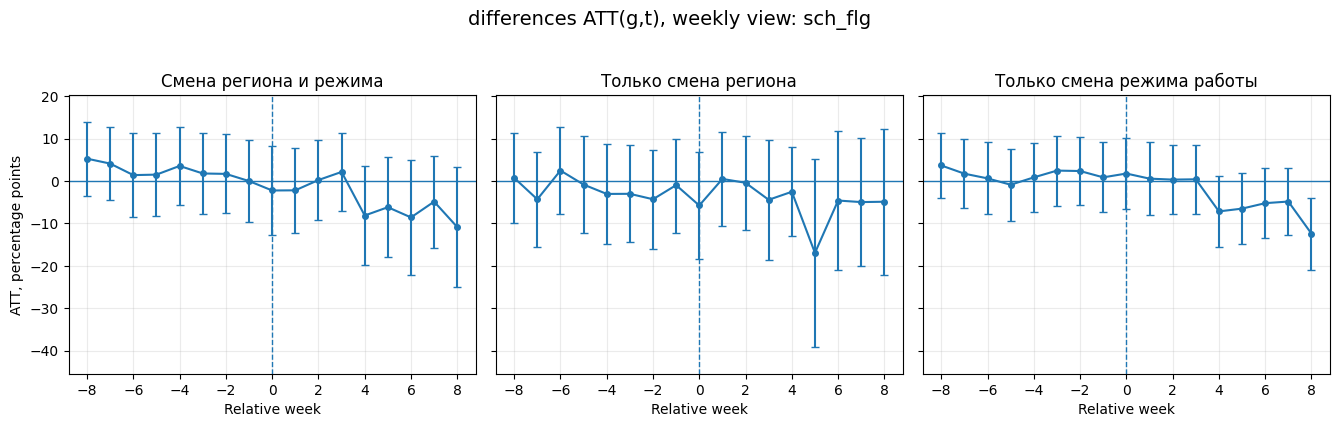

Saved: <PROJECT_ROOT>/…


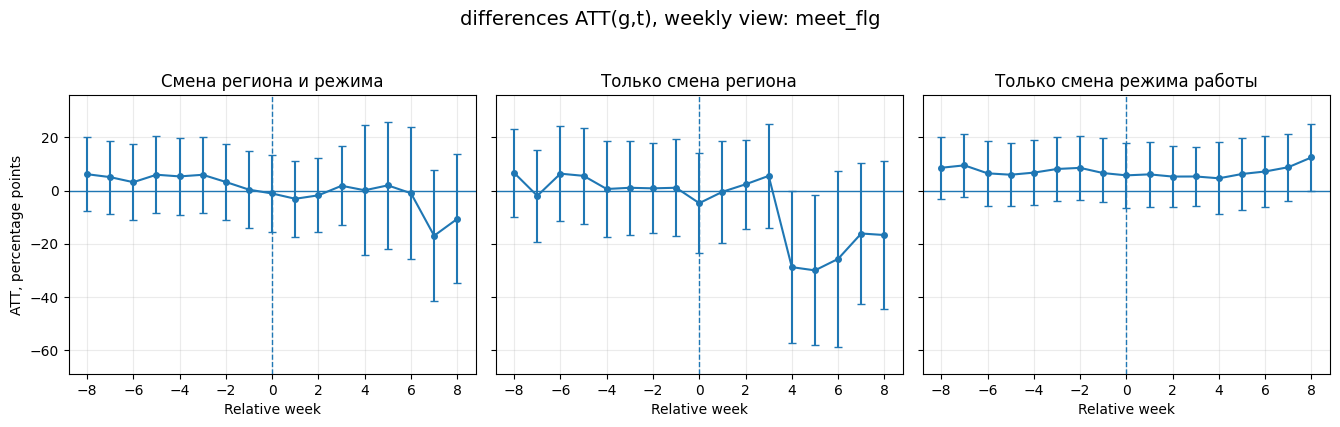

Saved: <PROJECT_ROOT>/…


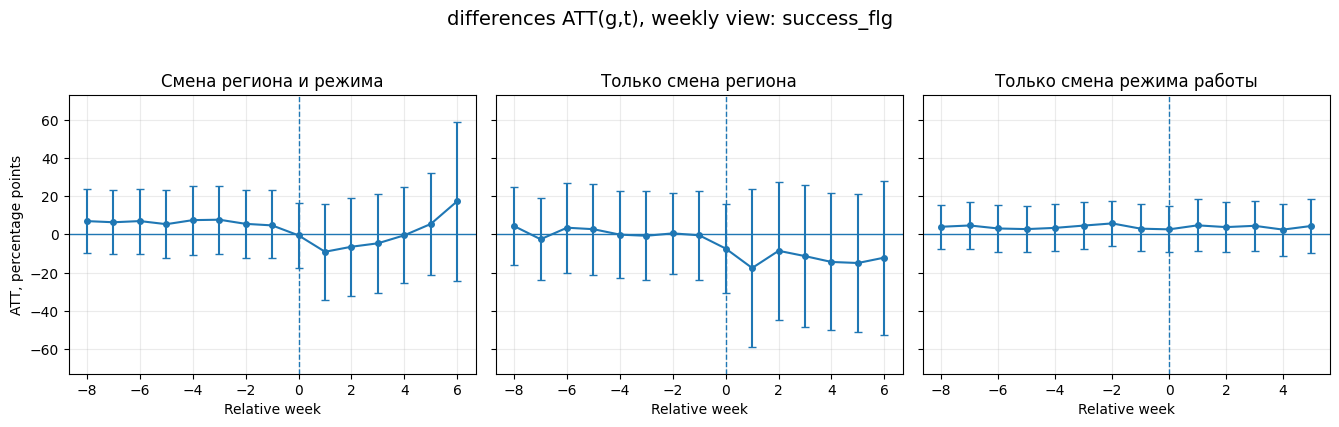

Saved: <PROJECT_ROOT>/…


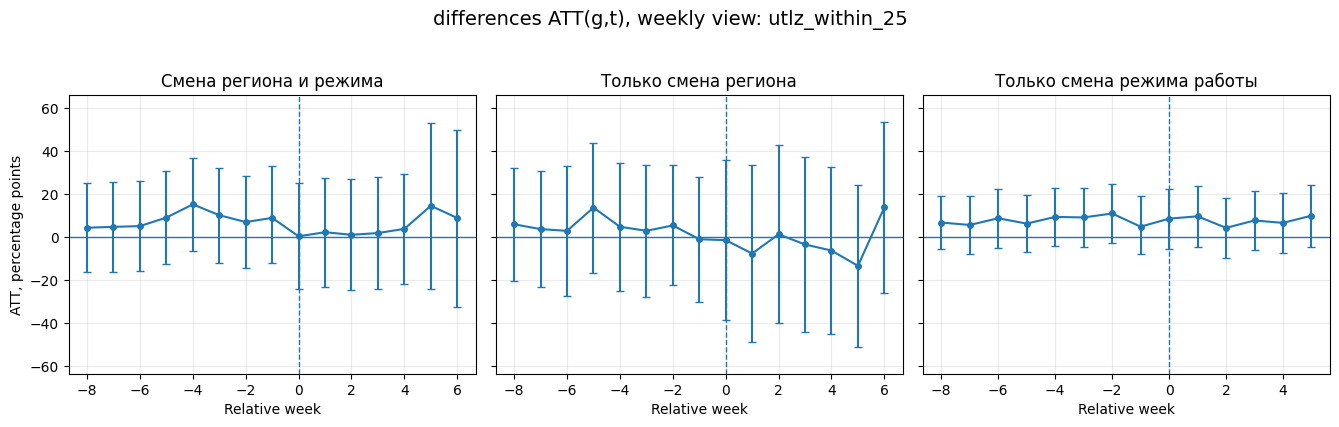

Saved: <PROJECT_ROOT>/…


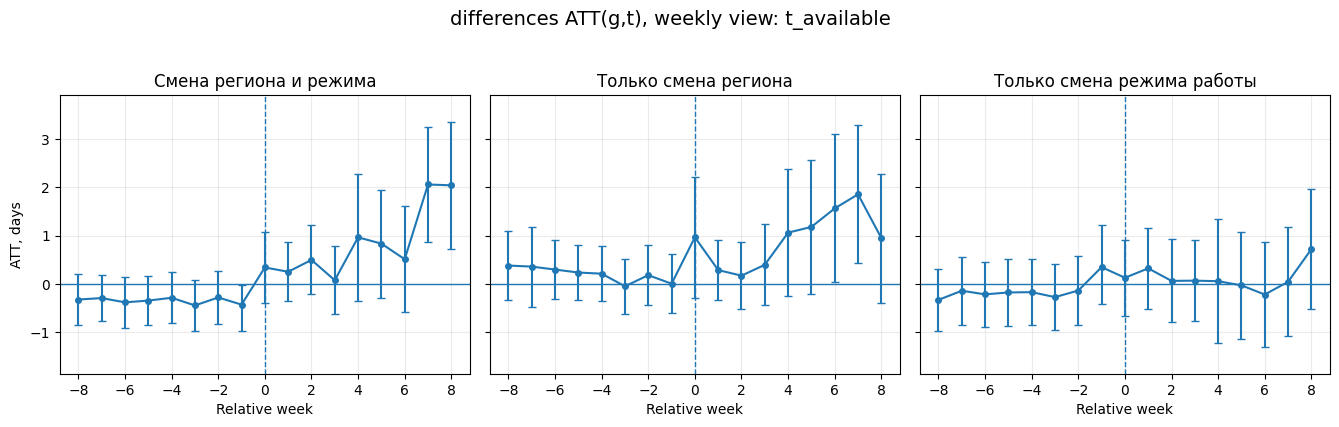

           outcome          change_type aggregation  cohort  base_period  \
0          sch_flg  region_and_workmode      simple     NaN          NaN   
1          sch_flg          region_only      simple     NaN          NaN   
2          sch_flg        workmode_only      simple     NaN          NaN   
3         meet_flg  region_and_workmode      simple     NaN          NaN   
4         meet_flg          region_only      simple     NaN          NaN   
5         meet_flg        workmode_only      simple     NaN          NaN   
6      success_flg  region_and_workmode      simple     NaN          NaN   
7      success_flg          region_only      simple     NaN          NaN   
8      success_flg        workmode_only      simple     NaN          NaN   
9   utlz_within_25  region_and_workmode      simple     NaN          NaN   
10  utlz_within_25          region_only      simple     NaN          NaN   
11  utlz_within_25        workmode_only      simple     NaN          NaN   
12     t_ava

In [21]:
def plot_differences_event_summary(event_df: pd.DataFrame, fig_dir=None):
    needed = {
        "aggregation",
        "relative_period",
        "estimate",
        "ci_lower",
        "ci_upper",
        "outcome",
        "change_type",
    }
    if event_df is None or event_df.empty or not needed.issubset(event_df.columns):
        print("No valid differences event-study results to plot.")
        return

    plot_df = event_df[
        (event_df["aggregation"] == "event")
        & event_df["relative_period"].notna()
        & event_df["estimate"].notna()
    ].copy()
    rel = pd.to_numeric(plot_df["relative_period"], errors="coerce")
    plot_df = plot_df[(rel >= -56) & (rel <= 56)].copy()
    if plot_df.empty:
        print("No valid differences event-study results to plot.")
        return

    plot_df["relative_week"] = np.floor(
        pd.to_numeric(plot_df["relative_period"], errors="coerce") / 7
    )
    weekly = (
        plot_df.groupby(["outcome", "change_type", "relative_week"], as_index=False)
        .agg(
            estimate=("estimate", "mean"),
            ci_lower=("ci_lower", "mean"),
            ci_upper=("ci_upper", "mean"),
        )
        .sort_values(["outcome", "change_type", "relative_week"])
    )

    for outcome in DIFFERENCES_OUTCOMES:
        sub_outcome = weekly[weekly["outcome"] == outcome].copy()
        if sub_outcome.empty:
            continue

        fig, axes = plt.subplots(1, len(TYPE_ORDER), figsize=(13.5, 4.1), sharey=True)
        lows = sub_outcome["ci_lower"].dropna().tolist()
        highs = sub_outcome["ci_upper"].dropna().tolist()
        y_lim = None
        if lows and highs:
            y_min, y_max = min(lows), max(highs)
            pad = 0.12 * (y_max - y_min if y_max > y_min else 1.0)
            y_lim = (y_min - pad, y_max + pad)

        for ax, ctype in zip(axes, TYPE_ORDER):
            sub = (
                sub_outcome[sub_outcome["change_type"] == ctype]
                .sort_values("relative_week")
                .copy()
            )
            ax.axhline(0, linewidth=1.0)
            ax.axvline(0, linestyle="--", linewidth=1.0)
            if not sub.empty:
                x = sub["relative_week"].to_numpy(dtype=float)
                y = sub["estimate"].to_numpy(dtype=float)
                yerr = np.vstack([
                    y - sub["ci_lower"].to_numpy(dtype=float),
                    sub["ci_upper"].to_numpy(dtype=float) - y,
                ])
                ax.errorbar(x, y, yerr=yerr, fmt="o-", linewidth=1.5, markersize=4, capsize=3)
            ax.set_title(TYPE_LABELS[ctype])
            ax.set_xlabel("Relative week")
            ax.grid(True, alpha=0.25)
            if y_lim is not None:
                ax.set_ylim(y_lim)

        unit_label = "days" if outcome == SPEED_OUTCOME else "percentage points"
        axes[0].set_ylabel(f"ATT, {unit_label}")
        fig.suptitle(
            f"differences ATT(g,t), weekly view: {outcome}",
            y=1.03,
            fontsize=14,
        )
        fig.tight_layout()

        if fig_dir is not None:
            out_path = Path(fig_dir) / f"differences_attgt_weekly_{outcome}.pdf"
            fig.savefig(out_path, bbox_inches="tight")
            print("Saved:", out_path)

        plt.show()


plot_differences_event_summary(differences_event_summary, fig_dir=FIG_DIR)

differences_post_average_summary



## анализ чувствительности: эмпирическое закрытие гексагонов

Отдельный блок не меняет основную DiD-спецификацию. Сравниваются:
- **A** — исходная CORE-выборка;
- **B** — CORE без `empirical_closed`;
- **C** — CORE только с достаточной pre-активностью и полным post-окном,
  без `empirical_closed`/`near_closed`.

Оценки берутся из `outputs/final/closure_did_sensitivity.csv` (тот же FE/cluster/событийная модель).
Нулевые дни в конверсионную панель не добавляются.


In [22]:
# closure empirical sensitivity
from pathlib import Path
import pandas as pd

closure_sens_path = PROJECT_ROOT / "outputs" / "final" / "closure_did_sensitivity.csv"
headline_path = PROJECT_ROOT / "outputs" / "hex_closure_headline_counts.csv"
cls_path = PROJECT_ROOT / "outputs" / "hex_empirical_closure_classification.csv"

if not closure_sens_path.exists():
    raise FileNotFoundError(
        f"Нет {closure_sens_path}. Сначала запустите scripts/run_hex_closure_diagnostics.py "
        "и scripts/run_closure_did_sensitivity.py"
    )

closure_did_sensitivity = pd.read_csv(closure_sens_path)
if headline_path.exists():
    display(pd.read_csv(headline_path))
if cls_path.exists():
    cls = pd.read_csv(cls_path)
    print("empirical_status:\n", cls["empirical_status"].value_counts())

cmp = (
    closure_did_sensitivity[closure_did_sensitivity["specification"].isin(["A", "B"])]
    .pivot_table(
        index=["outcome", "change_type"],
        columns="specification",
        values=["coef", "se", "ci_low", "ci_high", "p_value", "n_treated_hex", "n_hex_day"],
    )
)
display(closure_did_sensitivity.sort_values(["specification", "outcome", "change_type"]))
display(cmp)
print("Правила: A=CORE; B=CORE без empirical_closed; C=достаточная активность.")


,n_admin_closed,n_admin_closed_empirical_closed,n_admin_closed_orders_continue,n_core_empirical_closed,n_treated_classified
0,374,0,186,31,9327


empirical_status:
 empirical_status
insufficient_post_window    4809
sparse_pre_activity         3231
continues_active            1221
empirical_closed              65
near_closed                    1
Name: count, dtype: int64


[HTML-таблица сокращена: ~36 строк; см. сохранённый CSV при наличии экспорта]

                                     ci_high              ci_low            \
specification                              A         B         A         B   
outcome        change_type                                                   
meet_flg       region_and_workmode  0.032711  0.034178 -0.052177 -0.051019   
               region_only          0.069823  0.069797 -0.030257 -0.031182   
               workmode_only        0.036205  0.037912 -0.027537 -0.025951   
sch_flg        region_and_workmode  0.038537  0.039817 -0.019845 -0.018882   
               region_only          0.014330  0.010053 -0.054241 -0.057880   
               workmode_only        0.019756  0.019452 -0.025007 -0.025385   
success_flg    region_and_workmode  0.052603  0.053399 -0.041069 -0.040482   
               region_only          0.008861  0.010304 -0.111664 -0.111052   
               workmode_only        0.024867  0.026474 -0.042746 -0.041296   
utlz_within_25 region_and_workmode  0.069889  0.067793 -0.032538

Правила: A=CORE; B=CORE без empirical_closed; C=достаточная активность.


## Вывод

Средние постэффекты (п.п., region_and_workmode / region_only / workmode_only): `sch_flg` +0.93 / −2.00 / −0.26; `meet_flg` −0.97 / +1.98 / +0.43; `success_within_20` −0.72 / −5.98 / −0.54; `utlz_within_25` +1.87 / +2.73 / +1.04. Для всех основных конверсий доверительные интервалы включают ноль — статистически значимого эффекта не выявлено. `t_available` остаётся диагностикой: pretrends отвергаются, каузальная интерпретация скорости не поддерживается.
